# Predicción de NO₂ en Madrid — Notebook Unificado

Proyecto de Machine Learning · Bootcamp Data Science & IA (The Bridge)

Este notebook reúne el pipeline completo del proyecto, de principio a fin:

1. **Creación del dataset final** — unión de calidad del aire, tráfico y meteorología.
2. **Mini-EDA inicial** — primer vistazo y división train/test.
3. **Análisis del target (NO₂)** — distribución, outliers y variación temporal/espacial.
4. **Correlaciones entre features y outliers** — multicolinealidad y limpieza.
5. **Feature engineering (preprocesado)** — features temporales, lags, imputación y target encoding.
6. **Modelado, optimización y evaluación** — comparación de modelos, tuning y test final.

**Target**: `no2` (µg/m³) · **Periodo**: 2019–2024 · **24 estaciones** de Madrid.


---

# Parte 1 · Creación del Dataset Final


# Creación del Dataset Final - Contaminación, Tráfico y Meteorología en Madrid

En este notebook unimos los 5 ficheros originales para construir el dataset que usaremos en el EDA y el modelado.

**Target**: NO2 (nivel de contaminación)

**Features**: variables de tráfico y meteorología

**Pasos:**
1. Cargar los 5 CSV originales
2. Pasar calidad del aire y meteo de formato ancho a formato largo
3. Corregir la escala de las variables meteorológicas (problema de decimales)
4. Emparejar geográficamente estaciones de aire con tráfico y meteo cuando no comparten código
5. Unir todo y quedarnos con las columnas que nos interesan
6. Guardar el dataset final

## 1. Cargar los datos

In [15]:
import pandas as pd
import numpy as np

ruta = "../data_sample/"  # ajusta esta ruta segun donde tengas tu notebook

calidad_aire = pd.read_csv(ruta + "calidad_del_aire.csv", sep=";", encoding="utf-8-sig")
meteo_raw = pd.read_csv(ruta + "datos_meteorologicos.csv", sep=";", encoding="utf-8-sig")
estaciones_aire = pd.read_csv(ruta + "estaciones_control_aire.csv", sep=";", encoding="utf-8-sig")
estaciones_trafico = pd.read_csv(ruta + "estaciones_medicion_trafico.csv", sep=";", encoding="latin1")
# NOTA: el fichero trafico_diario.csv tiene un problema conocido en su cabecera
# (texto "git status" pegado por error delante de "fecha"). Por eso cargamos sin
# parse_dates y renombramos la primera columna manualmente, para que funcione
# sin importar el nombre exacto que tenga esa primera columna.
trafico = pd.read_csv(ruta + "trafico_diario.csv", sep=";", encoding="latin1")
trafico = trafico.rename(columns={trafico.columns[0]: "fecha"})
trafico["fecha"] = pd.to_datetime(trafico["fecha"])

print("Calidad del aire:", calidad_aire.shape)
print("Meteo:", meteo_raw.shape)
print("Estaciones aire:", estaciones_aire.shape)
print("Estaciones trafico:", estaciones_trafico.shape)
print("Trafico diario:", trafico.shape)

Calidad del aire: (9831, 69)
Meteo: (190564, 56)
Estaciones aire: (24, 25)
Estaciones trafico: (4962, 9)
Trafico diario: (5710123, 12)


In [16]:
prueba = pd.read_csv(ruta + "trafico_diario.csv", sep=";", nrows=3)
print(prueba.columns.tolist())
prueba

['git statusfecha', 'id_estacion_trafico', 'intensidad_mean', 'intensidad_max', 'ocupacion_mean', 'ocupacion_max', 'carga_mean', 'carga_max', 'vmed_mean', 'vmed_max', 'tipo_elem_moda', 'periodo_integracion_moda']


,git statusfecha,id_estacion_trafico,intensidad_mean,intensidad_max,ocupacion_mean,ocupacion_max,carga_mean,carga_max,vmed_mean,vmed_max,tipo_elem_moda,periodo_integracion_moda
0,2019-01-01,1001,2103.125,3096,8.489583,12.0,0.0,0,60.864583,65.0,M30,5
1,2019-01-01,1002,1402.750,3156,5.812500,13.0,0.0,0,68.072917,78.0,M30,5
2,2019-01-01,1003,1812.500,4248,5.854167,13.0,0.0,0,72.645833,93.0,M30,5


## 2. Calidad del aire: de formato ancho a formato largo

El fichero original tiene una columna por cada día del mes (D01, D02...D31) y su columna de validez (V01, V02...V31). 
Nos quedamos con el NO2 (código de magnitud = 8) y pasamos a tener una fila por estación y día.

In [17]:
# Nos quedamos solo con NO2 (magnitud 8)
no2 = calidad_aire[calidad_aire["MAGNITUD"] == 8].copy()

registros_no2 = []

for _, fila in no2.iterrows():
    for dia in range(1, 32):
        col_dato = f"D{dia:02d}"
        col_validez = f"V{dia:02d}"

        if col_dato not in fila or pd.isna(fila[col_dato]):
            continue
        if fila[col_validez] != "V":  # descartamos los no validos
            continue
        try:
            fecha = pd.Timestamp(year=int(fila["ANO"]), month=int(fila["MES"]), day=dia)
        except ValueError:
            continue  # dias que no existen en ese mes (ej 30 de febrero)

        registros_no2.append({
            "estacion": fila["ESTACION"],
            "fecha": fecha,
            "no2": fila[col_dato]
        })

no2_largo = pd.DataFrame(registros_no2)
print("NO2 en formato largo:", no2_largo.shape)
no2_largo.head()

NO2 en formato largo: (51001, 3)


,estacion,fecha,no2
0,4,2021-01-01,10
1,4,2021-01-02,23
2,4,2021-01-03,29
3,4,2021-01-04,29
4,4,2021-01-05,54


## 3. Meteorología: de formato ancho a formato largo + corrección de escala

Igual que antes, pero con horas (H01...H24) en vez de días. Calculamos la media diaria de cada variable.

**Importante - problema de datos detectado**: al comparar con la documentación oficial de datos.madrid.es, vimos que la temperatura, la velocidad del viento y la precipitacion habian perdido su punto decimal al exportar el fichero (ej. 12.9ºC aparecia como 129). Hay que dividir esas 3 variables entre 10 para corregirlo. La humedad y la presion ya estan en su escala correcta.

In [18]:
# Codigos de magnitud meteorologica que nos interesan
magnitudes_meteo = {83: "temperatura", 86: "humedad", 81: "viento_vel", 89: "precipitacion"}

meteo = meteo_raw[meteo_raw["MAGNITUD"].isin(magnitudes_meteo.keys())].copy()

registros_meteo = []

for _, fila in meteo.iterrows():
    valores_validos = []
    for h in range(1, 25):
        col_dato = f"H{h:02d}"
        col_validez = f"V{h:02d}"
        if col_validez in fila and fila[col_validez] == "V" and not pd.isna(fila[col_dato]):
            valores_validos.append(fila[col_dato])

    if not valores_validos:
        continue

    try:
        fecha = pd.Timestamp(year=int(fila["ANO"]), month=int(fila["MES"]), day=int(fila["DIA"]))
    except ValueError:
        continue

    registros_meteo.append({
        "estacion": fila["ESTACION"],
        "fecha": fecha,
        "magnitud": magnitudes_meteo[fila["MAGNITUD"]],
        "valor_medio_dia": np.mean(valores_validos)
    })

meteo_largo = pd.DataFrame(registros_meteo)

# Pivotamos para tener una columna por variable meteo
meteo_diario = meteo_largo.pivot_table(index=["estacion", "fecha"], columns="magnitud", values="valor_medio_dia").reset_index()

# Corregimos la escala (dividir entre 10)
meteo_diario["temperatura"] = meteo_diario["temperatura"] / 10
meteo_diario["viento_vel"] = meteo_diario["viento_vel"] / 10
meteo_diario["precipitacion"] = meteo_diario["precipitacion"] / 10

print("Meteo diaria:", meteo_diario.shape)
meteo_diario.describe()

Meteo diaria: (52712, 6)


magnitud,estacion,fecha,humedad,precipitacion,temperatura,viento_vel
count,52712.000000,52712,46390.000000,20751.000000,48412.000000,20553.000000
mean,69.353620,2021-12-21 04:12:54.745788160,55.296864,0.249373,15.362778,12.061642
min,4.000000,2019-01-01 00:00:00,0.000000,0.000000,-9.341667,0.020833
25%,36.000000,2020-06-05 00:00:00,39.000000,0.000000,9.362500,7.166667
50%,59.000000,2021-11-27 00:00:00,54.958333,0.000000,14.272373,10.431818
75%,108.000000,2023-07-31 00:00:00,70.791667,0.000000,21.333333,15.108333
max,115.000000,2024-12-31 00:00:00,1030.928571,22.795833,70.000000,1632.757143
std,39.374874,NaN,20.112194,1.104408,7.583599,13.334947


## 4. Emparejamiento geográfico

**El problema**: las estaciones de aire, de tráfico y de meteo están en sitios físicos distintos de Madrid. No podemos unir tablas por "nombre de estación" porque no coinciden.

**La solución**: usamos las coordenadas (latitud/longitud) de cada punto y calculamos la distancia real en el mapa entre ellos, para asignar a cada estación de aire su punto de tráfico y su estación meteo más cercanos.



In [19]:
# Esta funcion calcula la distancia en km entre dos puntos del mapa, dadas sus coordenadas.

def haversine(lon1, lat1, lon2, lat2):
    # paso 1: pasamos los grados a radianes (lo que necesita la formula matematica)
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    # paso 2: calculamos la diferencia entre las dos coordenadas
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    # paso 3: formula de la distancia sobre una esfera (la Tierra)
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    # paso 4: 6371 es el radio de la Tierra en km, lo usamos para convertir el resultado a km
    return 6371 * 2 * np.arcsin(np.sqrt(a))

In [20]:

estaciones_con_meteo = [4, 8, 16, 18, 24, 35, 36, 38, 39, 54, 56, 58, 59]

aire_con_meteo = estaciones_aire[estaciones_aire["CODIGO_CORTO"].isin(estaciones_con_meteo)]
aire_sin_meteo = estaciones_aire[~estaciones_aire["CODIGO_CORTO"].isin(estaciones_con_meteo)]


mapa_meteo = {e: e for e in estaciones_con_meteo}  # las que ya tienen, se asignan a si mismas
distancia_meteo = {e: 0.0 for e in estaciones_con_meteo}  # distancia 0 porque es la misma estacion

for _, fila in aire_sin_meteo.iterrows():
    distancias = haversine(fila["LONGITUD"], fila["LATITUD"], aire_con_meteo["LONGITUD"], aire_con_meteo["LATITUD"])
    estacion_mas_cercana = aire_con_meteo.loc[distancias.idxmin(), "CODIGO_CORTO"]
    mapa_meteo[fila["CODIGO_CORTO"]] = estacion_mas_cercana
    distancia_meteo[fila["CODIGO_CORTO"]] = round(distancias.min(), 2)

print("Mapa de meteo asignada:")
print(mapa_meteo)
print()
print("Distancias (km) de cada emparejamiento de meteo:")
print(distancia_meteo)

Mapa de meteo asignada:
{4: 4, 8: 8, 16: 16, 18: 18, 24: 24, 35: 35, 36: 36, 38: 38, 39: 39, 54: 54, 56: 56, 58: 58, 59: 59, 11: np.int64(38), 17: np.int64(56), 27: np.int64(59), 40: np.int64(36), 47: np.int64(8), 48: np.int64(38), 49: np.int64(8), 50: np.int64(39), 55: np.int64(59), 57: np.int64(39), 60: np.int64(39)}

Distancias (km) de cada emparejamiento de meteo:
{4: 0.0, 8: 0.0, 16: 0.0, 18: 0.0, 24: 0.0, 35: 0.0, 36: 0.0, 38: 0.0, 39: 0.0, 54: 0.0, 56: 0.0, 58: 0.0, 59: 0.0, 11: np.float64(2.6), 17: np.float64(4.24), 27: np.float64(2.78), 40: np.float64(2.26), 47: np.float64(2.64), 48: np.float64(1.55), 49: np.float64(0.79), 50: np.float64(2.39), 55: np.float64(2.43), 57: np.float64(4.67), 60: np.float64(3.09)}


In [21]:
# Ahora buscamos el punto de trafico mas cercano para CADA estacion de aire (las 24)
# Tambien guardamos la distancia, para poder valorar despues la fiabilidad del emparejamiento
mapa_trafico = {}
distancia_trafico = {}

for _, fila in estaciones_aire.iterrows():
    distancias = haversine(fila["LONGITUD"], fila["LATITUD"], estaciones_trafico["longitud"], estaciones_trafico["latitud"])
    id_mas_cercano = estaciones_trafico.loc[distancias.idxmin(), "id"]
    mapa_trafico[fila["CODIGO_CORTO"]] = id_mas_cercano
    distancia_trafico[fila["CODIGO_CORTO"]] = round(distancias.min(), 3)

print("Mapa de trafico asignado:")
print(mapa_trafico)
print()
print("Distancias (km) de cada emparejamiento de trafico:")
print(distancia_trafico)

Mapa de trafico asignado:
{4: np.int64(4284), 8: np.int64(4028), 11: np.int64(3914), 16: np.int64(3791), 17: np.int64(4848), 18: np.int64(5058), 24: np.int64(3546), 27: np.int64(6928), 35: np.int64(3731), 36: np.int64(10890), 38: np.int64(3411), 39: np.int64(5416), 40: np.int64(5783), 47: np.int64(4129), 48: np.int64(4461), 49: np.int64(10080), 50: np.int64(5465), 54: np.int64(5365), 55: np.int64(6348), 56: np.int64(11007), 57: np.int64(9870), 58: np.int64(6547), 59: np.int64(9855), 60: np.int64(6573)}

Distancias (km) de cada emparejamiento de trafico:
{4: np.float64(0.06), 8: np.float64(0.075), 11: np.float64(0.052), 16: np.float64(0.08), 17: np.float64(0.213), 18: np.float64(0.488), 24: np.float64(1.182), 27: np.float64(0.168), 35: np.float64(0.03), 36: np.float64(0.03), 38: np.float64(0.068), 39: np.float64(0.049), 40: np.float64(0.133), 47: np.float64(0.152), 48: np.float64(0.088), 49: np.float64(0.433), 50: np.float64(0.149), 54: np.float64(0.377), 55: np.float64(0.47), 56: np.fl

**¿Qué acabamos de hacer?** Para cada una de las 24 estaciones de aire, hemos calculado "cuál es el punto de tráfico más cercano" y "cuál es la estación con meteo más cercana" (si no tenía la suya propia). El resultado son dos listas (`mapa_meteo` y `mapa_trafico`) tipo *"la estación X usa el tráfico del punto Y"*.

También guardamos la distancia de cada emparejamiento. Si algún día vemos una distancia muy grande (varios km), sabremos que ese dato es menos fiable, porque el punto de tráfico o meteo asignado no está realmente al lado de la estación de aire.

## 5. Unión final

Unimos NO2 (target) + meteo + trafico, usando los mapas de emparejamiento que acabamos de calcular.

In [22]:
# Añadimos las columnas de emparejamiento a la tabla de NO2
no2_largo["estacion_meteo"] = no2_largo["estacion"].map(mapa_meteo)
no2_largo["id_trafico"] = no2_largo["estacion"].map(mapa_trafico)

# Añadimos tambien las distancias, para poder valorar la fiabilidad del emparejamiento en el EDA
no2_largo["distancia_meteo_km"] = no2_largo["estacion"].map(distancia_meteo)
no2_largo["distancia_trafico_km"] = no2_largo["estacion"].map(distancia_trafico)

# Union con meteo (por estacion_meteo y fecha)
meteo_para_unir = meteo_diario.rename(columns={"estacion": "estacion_meteo"})
dataset = no2_largo.merge(meteo_para_unir, on=["estacion_meteo", "fecha"], how="left")

# Union con trafico (por id_trafico y fecha)
trafico_para_unir = trafico.rename(columns={"id_estacion_trafico": "id_trafico"})
dataset = dataset.merge(trafico_para_unir, on=["id_trafico", "fecha"], how="left")

print("Dataset unido:", dataset.shape)
dataset.head()

Dataset unido: (51001, 21)


,estacion,fecha,no2,estacion_meteo,id_trafico,distancia_meteo_km,distancia_trafico_km,humedad,precipitacion,temperatura,...,intensidad_mean,intensidad_max,ocupacion_mean,ocupacion_max,carga_mean,carga_max,vmed_mean,vmed_max,tipo_elem_moda,periodo_integracion_moda
0,4,2021-01-01,10,4,4284,0.0,0.06,NaN,NaN,4.070833,...,388.155556,916.0,3.522222,8.0,21.722222,50.0,0.0,0.0,URB,15.0
1,4,2021-01-02,23,4,4284,0.0,0.06,NaN,NaN,2.387500,...,516.344828,924.0,4.574713,8.0,28.563218,49.0,0.0,0.0,URB,15.0
2,4,2021-01-03,29,4,4284,0.0,0.06,NaN,NaN,2.233333,...,476.076923,924.0,4.109890,9.0,26.329670,50.0,0.0,0.0,URB,15.0
3,4,2021-01-04,29,4,4284,0.0,0.06,NaN,NaN,3.016667,...,677.088235,998.0,5.911765,8.0,37.044118,54.0,0.0,0.0,URB,15.0
4,4,2021-01-05,54,4,4284,0.0,0.06,NaN,NaN,0.250000,...,588.095745,922.0,4.978723,9.0,32.202128,49.0,0.0,0.0,URB,15.0


## 6. Nos quedamos con las columnas que nos interesan

In [23]:
columnas_utiles = [
    "estacion", "fecha", "no2",                                      
    "temperatura", "humedad", "viento_vel", "precipitacion",         
    "intensidad_mean", "intensidad_max",                              
    "ocupacion_mean", "carga_mean",
    "vmed_mean", "vmed_max",                                          
    "tipo_elem_moda",                                                 
    "distancia_meteo_km", "distancia_trafico_km"                      
]

df = dataset[columnas_utiles].copy()

print("Dataset final:", df.shape)
print()
print("Nulos por columna:")
print(df.isna().sum())
df.head()

Dataset final: (51001, 16)

Nulos por columna:
estacion                    0
fecha                       0
no2                         0
temperatura              5796
humedad                  4182
viento_vel              36316
precipitacion           27679
intensidad_mean         20832
intensidad_max          20832
ocupacion_mean          20849
carga_mean              20832
vmed_mean               20832
vmed_max                20832
tipo_elem_moda          20832
distancia_meteo_km          0
distancia_trafico_km        0
dtype: int64


,estacion,fecha,no2,temperatura,humedad,viento_vel,precipitacion,intensidad_mean,intensidad_max,ocupacion_mean,carga_mean,vmed_mean,vmed_max,tipo_elem_moda,distancia_meteo_km,distancia_trafico_km
0,4,2021-01-01,10,4.070833,NaN,NaN,NaN,388.155556,916.0,3.522222,21.722222,0.0,0.0,URB,0.0,0.06
1,4,2021-01-02,23,2.387500,NaN,NaN,NaN,516.344828,924.0,4.574713,28.563218,0.0,0.0,URB,0.0,0.06
2,4,2021-01-03,29,2.233333,NaN,NaN,NaN,476.076923,924.0,4.109890,26.329670,0.0,0.0,URB,0.0,0.06
3,4,2021-01-04,29,3.016667,NaN,NaN,NaN,677.088235,998.0,5.911765,37.044118,0.0,0.0,URB,0.0,0.06
4,4,2021-01-05,54,0.250000,NaN,NaN,NaN,588.095745,922.0,4.978723,32.202128,0.0,0.0,URB,0.0,0.06


**¿Qué acabamos de hacer?** De toda la tabla (que tenía columnas de sobra, como IDs internos), nos quedamos solo con las que vamos a usar de verdad: la fecha, la estación, el NO2 (target) y las features de meteo y tráfico.



## 7. Guardar el dataset final

In [24]:
df.to_parquet(ruta + "df.parquet", index=False)
print("Guardado en", ruta + "df.parquet")

Guardado en ../data_sample/df.parquet


---

# Parte 2 · Mini-EDA Inicial y división Train/Test


# Mini-EDA Inicial



In [1]:
import pandas as pd

ruta = "../data_sample/"
df = pd.read_parquet(ruta + "df.parquet")
print("Filas y columnas:", df.shape)

Filas y columnas: (51001, 16)


In [2]:
df.head()

,estacion,fecha,no2,temperatura,humedad,viento_vel,precipitacion,intensidad_mean,intensidad_max,ocupacion_mean,carga_mean,vmed_mean,vmed_max,tipo_elem_moda,distancia_meteo_km,distancia_trafico_km
0,4,2021-01-01,10,4.070833,NaN,NaN,NaN,388.155556,916.0,3.522222,21.722222,0.0,0.0,URB,0.0,0.06
1,4,2021-01-02,23,2.387500,NaN,NaN,NaN,516.344828,924.0,4.574713,28.563218,0.0,0.0,URB,0.0,0.06
2,4,2021-01-03,29,2.233333,NaN,NaN,NaN,476.076923,924.0,4.109890,26.329670,0.0,0.0,URB,0.0,0.06
3,4,2021-01-04,29,3.016667,NaN,NaN,NaN,677.088235,998.0,5.911765,37.044118,0.0,0.0,URB,0.0,0.06
4,4,2021-01-05,54,0.250000,NaN,NaN,NaN,588.095745,922.0,4.978723,32.202128,0.0,0.0,URB,0.0,0.06


In [3]:
df.dtypes

estacion                         int64
fecha                   datetime64[ns]
no2                              int64
temperatura                    float64
humedad                        float64
viento_vel                     float64
precipitacion                  float64
intensidad_mean                float64
intensidad_max                 float64
ocupacion_mean                 float64
carga_mean                     float64
vmed_mean                      float64
vmed_max                       float64
tipo_elem_moda                  object
distancia_meteo_km             float64
distancia_trafico_km           float64
dtype: object

In [4]:
df.isna().sum()

estacion                    0
fecha                       0
no2                         0
temperatura              5796
humedad                  4182
viento_vel              36316
precipitacion           27679
intensidad_mean         20832
intensidad_max          20832
ocupacion_mean          20849
carga_mean              20832
vmed_mean               20832
vmed_max                20832
tipo_elem_moda          20832
distancia_meteo_km          0
distancia_trafico_km        0
dtype: int64

In [5]:
df.describe()

,estacion,fecha,no2,temperatura,humedad,viento_vel,precipitacion,intensidad_mean,intensidad_max,ocupacion_mean,carga_mean,vmed_mean,vmed_max,distancia_meteo_km,distancia_trafico_km
count,51001.000000,51001,51001.000000,45205.000000,46819.000000,14685.000000,23322.000000,30169.000000,30169.000000,30152.000000,30169.000000,30169.000000,30169.000000,51001.000000,51001.000000
mean,38.014529,2021-12-15 08:15:44.734416896,28.126605,15.757887,57.490821,11.738778,0.261186,328.847147,752.908449,5.222777,16.832013,2.881174,4.853757,1.238171,0.381044
min,4.000000,2019-01-01 00:00:00,1.000000,-6.125000,15.583333,0.325000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.022000
25%,24.000000,2020-06-22 00:00:00,15.000000,9.866667,41.541667,7.595833,0.000000,116.073684,305.000000,1.427083,8.270833,0.000000,0.000000,0.000000,0.068000
50%,40.000000,2021-12-12 00:00:00,24.000000,14.762500,56.875000,10.313043,0.000000,272.625000,583.000000,2.916667,16.843750,0.000000,0.000000,0.000000,0.152000
75%,55.000000,2023-06-13 00:00:00,37.000000,21.516667,72.541667,14.283333,0.000000,510.260417,1060.000000,5.375000,24.395833,0.000000,0.000000,2.600000,0.433000
max,60.000000,2024-11-30 00:00:00,148.000000,34.512500,100.000000,60.375000,22.795833,36504.854167,99999.000000,100.000000,99.500000,120.000000,122.000000,4.670000,3.713000
std,17.473312,NaN,16.937192,7.360752,18.879570,6.219249,1.106183,428.740978,1822.129796,8.482303,10.744891,11.522382,19.037327,1.508691,0.743760


In [6]:
print("Numero de estaciones distintas:", df["estacion"].nunique())
print("Fecha mas antigua:", df["fecha"].min())
print("Fecha mas reciente:", df["fecha"].max())

Numero de estaciones distintas: 24
Fecha mas antigua: 2019-01-01 00:00:00
Fecha mas reciente: 2024-11-30 00:00:00


## Tabla de variables

Aquí documentamos, columna por columna, qué es cada variable, qué tipo de dato tiene, y qué papel juega en el proyecto (target, feature, o auxiliar). Es el mapa de referencia al que volver cuando tengas dudas de qué es cada cosa.

In [7]:
tabla_variables = pd.DataFrame([
    {"variable": "estacion",             "tipo": "int",   "naturaleza": "identificador", "rol": "ID",       "observaciones": "codigo de la estacion de aire (24 valores distintos)"},
    {"variable": "fecha",                "tipo": "fecha", "naturaleza": "temporal",       "rol": "ID",       "observaciones": "dia de la medicion, 2019-2024"},
    {"variable": "no2",                  "tipo": "float", "naturaleza": "numerica",       "rol": "TARGET",   "observaciones": "nivel de NO2, lo que queremos predecir"},
    {"variable": "temperatura",          "tipo": "float", "naturaleza": "numerica",       "rol": "feature",  "observaciones": "corregida (se dividio entre 10), en grados C"},
    {"variable": "humedad",              "tipo": "float", "naturaleza": "numerica",       "rol": "feature",  "observaciones": "en % (0-100)"},
    {"variable": "viento_vel",           "tipo": "float", "naturaleza": "numerica",       "rol": "feature",  "observaciones": "corregida (se dividio entre 10), en m/s"},
    {"variable": "precipitacion",        "tipo": "float", "naturaleza": "numerica",       "rol": "feature",  "observaciones": "corregida (se dividio entre 10), en mm"},
    {"variable": "intensidad_mean",      "tipo": "float", "naturaleza": "numerica",       "rol": "feature",  "observaciones": "intensidad media de trafico del dia"},
    {"variable": "intensidad_max",       "tipo": "float", "naturaleza": "numerica",       "rol": "feature",  "observaciones": "pico maximo de trafico del dia"},
    {"variable": "ocupacion_mean",       "tipo": "float", "naturaleza": "numerica",       "rol": "feature",  "observaciones": "% de ocupacion media de la via"},
    {"variable": "carga_mean",           "tipo": "float", "naturaleza": "numerica",       "rol": "feature",  "observaciones": "indice de carga de trafico"},
    {"variable": "vmed_mean",            "tipo": "float", "naturaleza": "numerica",       "rol": "feature",  "observaciones": "velocidad media de circulacion"},
    {"variable": "vmed_max",             "tipo": "float", "naturaleza": "numerica",       "rol": "feature",  "observaciones": "velocidad maxima registrada"},
    {"variable": "tipo_elem_moda",       "tipo": "texto", "naturaleza": "categorica",     "rol": "feature",  "observaciones": "M30 (autovia urbana) o URB (calle normal)"},
    {"variable": "distancia_meteo_km",   "tipo": "float", "naturaleza": "numerica",       "rol": "auxiliar", "observaciones": "distancia a la estacion meteo usada (0 = propia)"},
    {"variable": "distancia_trafico_km", "tipo": "float", "naturaleza": "numerica",       "rol": "auxiliar", "observaciones": "distancia al punto de trafico usado"},
])

tabla_variables

,variable,tipo,naturaleza,rol,observaciones
0,estacion,int,identificador,ID,codigo de la estacion de aire (24 valores dist...
1,fecha,fecha,temporal,ID,"dia de la medicion, 2019-2024"
2,no2,float,numerica,TARGET,"nivel de NO2, lo que queremos predecir"
3,temperatura,float,numerica,feature,"corregida (se dividio entre 10), en grados C"
4,humedad,float,numerica,feature,en % (0-100)
5,viento_vel,float,numerica,feature,"corregida (se dividio entre 10), en m/s"
6,precipitacion,float,numerica,feature,"corregida (se dividio entre 10), en mm"
7,intensidad_mean,float,numerica,feature,intensidad media de trafico del dia
8,intensidad_max,float,numerica,feature,pico maximo de trafico del dia
9,ocupacion_mean,float,numerica,feature,% de ocupacion media de la via


## División train/test

In [8]:
from sklearn.model_selection import train_test_split

# 80% para train, 20% para test. random_state fija la "semilla" para que el reparto
# salga siempre igual si se vuelve a ejecutar (reproducibilidad)
train, test = train_test_split(df, test_size=0.2, random_state=42)

print("Train:", train.shape)
print("Test:", test.shape)

Train: (40800, 16)
Test: (10201, 16)


**¿Qué significa esto?** `train_test_split` coge tu tabla y la reparte al azar en dos trozos: el 80% de las filas van a `train` (con lo que vamos a trabajar de aquí en adelante) y el 20% a `test` (que se queda guardado, sin tocar).

In [9]:
train.to_parquet(ruta + "train.parquet", index=False)
test.to_parquet(ruta + "test.parquet", index=False)

print("Guardados train.parquet y test.parquet en", ruta)

Guardados train.parquet y test.parquet en ../data_sample/


---

# Parte 3 · Análisis del Target (NO2)


# Análisis del Target: NO2

Aquí analizamos en profundidad nuestra variable objetivo (NO2), trabajando **solo con `train.csv`** .

**Qué vamos a ver:**
1. Distribución (histograma, ¿simétrica o asimétrica?)
2. Estadísticos básicos
3. Detección de outliers (IQR y Z-score)
4. Variación temporal (mes, día de la semana)
5. Variación por estación de medición

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ruta = "../data_sample/"
train = pd.read_parquet(ruta + "train.parquet")

print("Train:", train.shape)
train["no2"].describe()

Train: (40800, 16)


count    40800.000000
mean        28.138529
std         16.958338
min          1.000000
25%         15.000000
50%         24.000000
75%         37.000000
max        148.000000
Name: no2, dtype: float64

## 1. Distribución del target

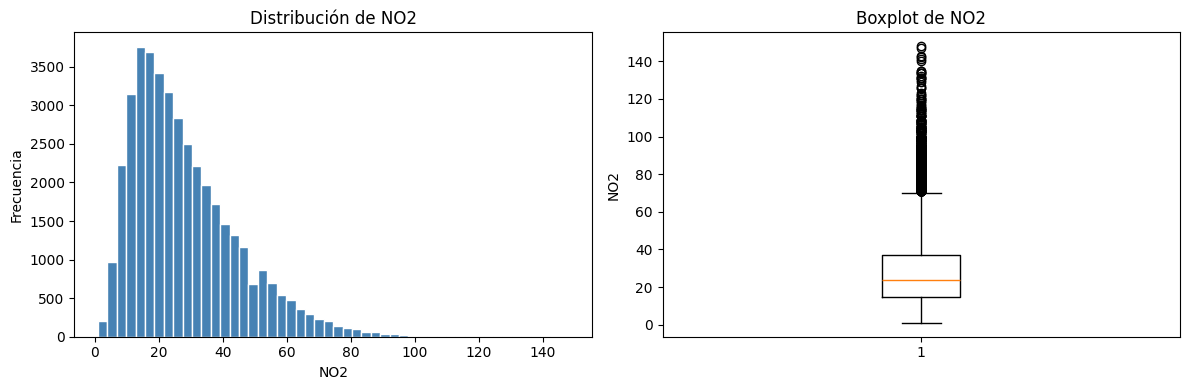

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma: para ver la forma de la distribucion
axes[0].hist(train["no2"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribución de NO2")
axes[0].set_xlabel("NO2")
axes[0].set_ylabel("Frecuencia")

# Boxplot: para ver la mediana, los cuartiles y los outliers de un vistazo
axes[1].boxplot(train["no2"], vert=True)
axes[1].set_title("Boxplot de NO2")
axes[1].set_ylabel("NO2")

plt.tight_layout()
plt.show()

**¿Qué significa esto?**

- **Histograma**: cada barra representa cuántos días tuvieron un nivel de NO2 en ese rango. Si la mayoría de barras están a la izquierda y hay una "cola" larga hacia la derecha, la distribución está **sesgada a la derecha** (asimétrica) — es habitual en variables de contaminación, porque hay muchos días "normales" y pocos días con picos muy altos.

- **Boxplot** (diagrama de caja): la caja representa donde está el 50% central de los datos, la línea del medio es la mediana, y los puntos sueltos por encima o por debajo de los "bigotes" son los outliers — valores que se salen claramente de lo normal.

In [3]:
media = train["no2"].mean()
mediana = train["no2"].median()
asimetria = train["no2"].skew()

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Asimetria (skew): {asimetria:.2f}")

Media: 28.14
Mediana: 24.00
Asimetria (skew): 1.23




- Si **media > mediana** → hay una cola de valores altos tirando de la media hacia arriba (sesgo a la derecha)
- **Asimetría (skew)**: es un número que resume la forma de la distribución
  - Cerca de 0 → simétrica
  - Mayor que 0 → sesgada a la derecha (cola larga hacia valores altos)
  - Menor que 0 → sesgada a la izquierda

  Como referencia: valores entre -0.5 y 0.5 se consideran razonablemente simétricos; por encima de 1 (en valor absoluto) ya es una asimetría marcada. Esto es información útil para el equipo de preprocesado: si el target está muy sesgado, podrían plantearse aplicar una transformación (ej. logaritmo) antes de modelar.

## 2. Detección de outliers

In [4]:
# Metodo IQR (rango intercuartilico)
q1 = train["no2"].quantile(0.25)
q3 = train["no2"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers_iqr = train[(train["no2"] < limite_inferior) | (train["no2"] > limite_superior)]

print(f"Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}, Limite superior: {limite_superior:.2f}")
print(f"Numero de outliers (IQR): {len(outliers_iqr)} de {len(train)} ({len(outliers_iqr)/len(train)*100:.1f}%)")

Q1: 15.00, Q3: 37.00, IQR: 22.00
Limite inferior: -18.00, Limite superior: 70.00
Numero de outliers (IQR): 935 de 40800 (2.3%)


**¿Qué significa esto?** El método IQR (rango intercuartílico) mira dónde está el 50% central de los datos (entre Q1 y Q3) y marca como outlier todo lo que se aleje demasiado de ahí (1.5 veces el ancho de ese rango central, por encima o por debajo). Es el mismo criterio que usa el boxplot de arriba para dibujar los puntos sueltos.

In [5]:
# Metodo Z-score (cuantas desviaciones estandar se aleja cada valor de la media)
media = train["no2"].mean()
desviacion = train["no2"].std()

z_scores = (train["no2"] - media) / desviacion
outliers_zscore = train[z_scores.abs() > 3]

print(f"Numero de outliers (Z-score > 3): {len(outliers_zscore)} de {len(train)} ({len(outliers_zscore)/len(train)*100:.1f}%)")

Numero de outliers (Z-score > 3): 442 de 40800 (1.1%)


**¿Qué significa esto?** El Z-score mide cuántas "desviaciones estándar" se aleja cada valor de la media. Por ejemplo, un Z-score de 3 significa que ese valor está muy lejos de lo normal (en una distribución simétrica, solo el 0.3% de los datos deberían tener un Z-score mayor que 3). Por eso usamos ese 3 como límite para marcar outliers.



## 3. Variación temporal

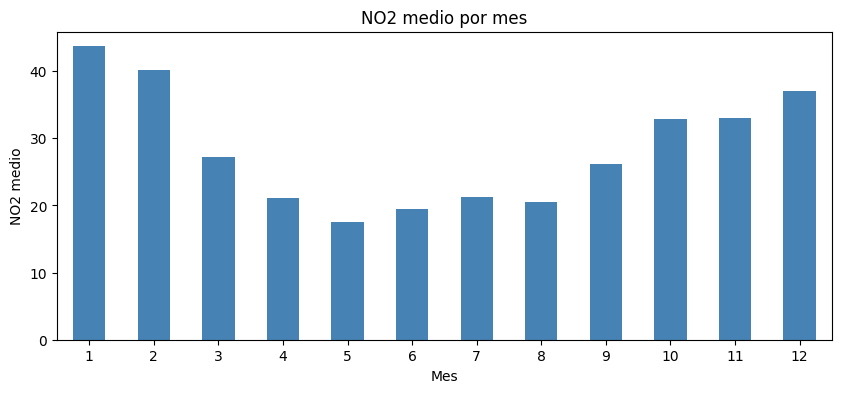

In [6]:
# Creamos columnas auxiliares a partir de la fecha
train["mes"] = train["fecha"].dt.month
train["dia_semana"] = train["fecha"].dt.day_name()
train["es_fin_de_semana"] = train["fecha"].dt.dayofweek >= 5  # 5=sabado, 6=domingo

no2_por_mes = train.groupby("mes")["no2"].mean()

plt.figure(figsize=(10, 4))
no2_por_mes.plot(kind="bar", color="steelblue")
plt.title("NO2 medio por mes")
plt.xlabel("Mes")
plt.ylabel("NO2 medio")
plt.xticks(rotation=0)
plt.show()

**¿Qué significa esto?** Creamos 3 columnas nuevas a partir de la fecha (mes, nombre del día de la semana, y si es fin de semana), y agrupamos el NO2 por mes para ver si hay estacionalidad. Es habitual que la contaminación sea más alta en invierno (más calefacción, menos dispersión del aire) y más baja en verano — este gráfico nos dice si eso se cumple también en Madrid con nuestros datos.

Día laboral      29.904141
Fin de semana    23.760788
Name: no2, dtype: float64


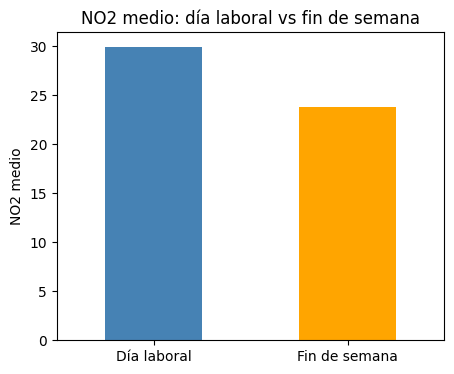

In [7]:
no2_finde_vs_laboral = train.groupby("es_fin_de_semana")["no2"].mean()
no2_finde_vs_laboral.index = ["Día laboral", "Fin de semana"]

print(no2_finde_vs_laboral)

plt.figure(figsize=(5, 4))
no2_finde_vs_laboral.plot(kind="bar", color=["steelblue", "orange"])
plt.title("NO2 medio: día laboral vs fin de semana")
plt.ylabel("NO2 medio")
plt.xticks(rotation=0)
plt.show()

**¿Qué significa esto?** Comparamos el NO2 medio entre días laborales y fines de semana. Si nuestra hipótesis de negocio es correcta (más tráfico → más NO2), esperaríamos ver un NO2 más bajo el fin de semana, cuando hay menos coches circulando — sobre todo menos tráfico de "ir a trabajar".

## 4. Variación por estación de medición

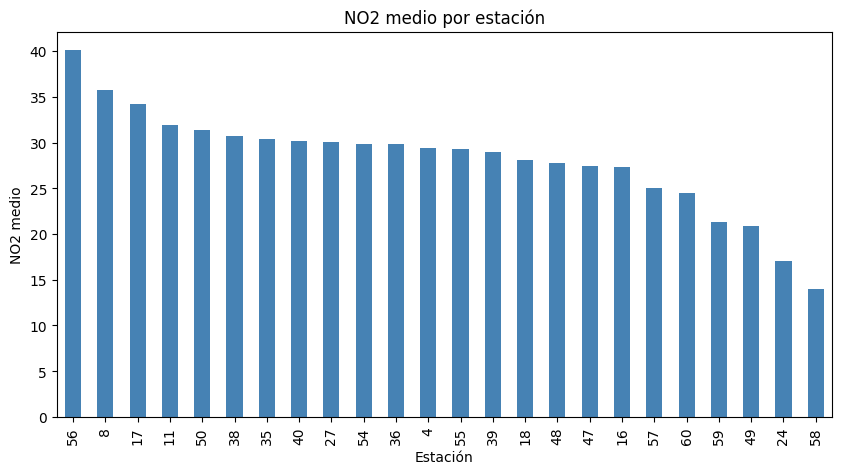

In [8]:
no2_por_estacion = train.groupby("estacion")["no2"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
no2_por_estacion.plot(kind="bar", color="steelblue")
plt.title("NO2 medio por estación")
plt.xlabel("Estación")
plt.ylabel("NO2 medio")
plt.show()

**¿Qué significa esto?** Cada barra es una estación de medición (24 en total), ordenadas de más a menos contaminada de media. Esto nos dice si hay zonas de Madrid sistemáticamente más contaminadas que otras (probablemente las de más tráfico, como Plaza Elíptica o la M30, frente a zonas más residenciales o parques como El Pardo).

## 5. Relación tráfico vs. NO2

Ahora cambiamos de pregunta: ya no miramos el target solo, sino cómo se relaciona con cada feature. Empezamos por el tráfico.

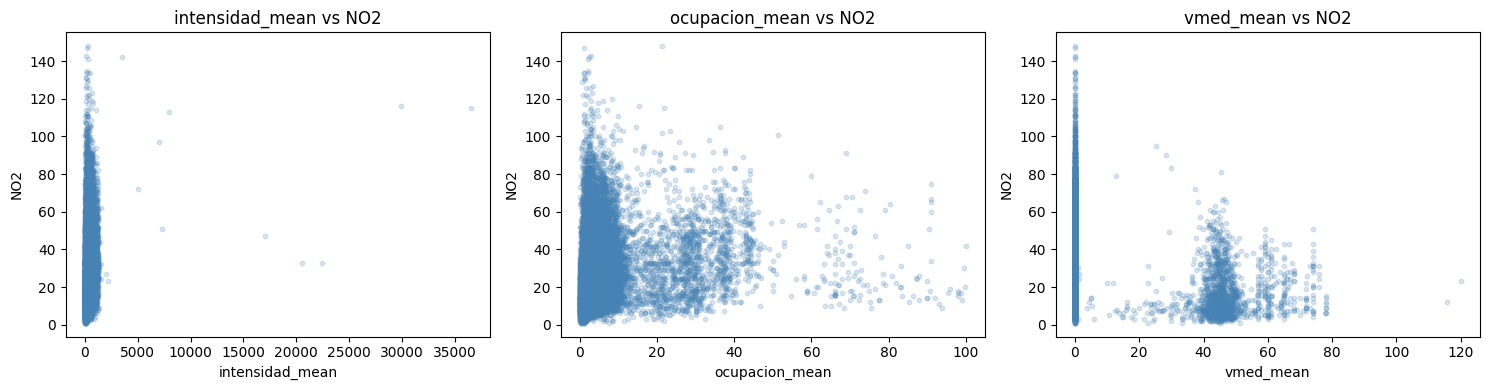

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

variables_trafico = ["intensidad_mean", "ocupacion_mean", "vmed_mean"]

for ax, variable in zip(axes, variables_trafico):
    ax.scatter(train[variable], train["no2"], alpha=0.2, s=10, color="steelblue")
    ax.set_xlabel(variable)
    ax.set_ylabel("NO2")
    ax.set_title(f"{variable} vs NO2")

plt.tight_layout()
plt.show()

**¿Qué significa esto?** Un scatter plot pone un punto por cada día: en el eje X la variable de tráfico, en el eje Y el NO2 de ese mismo día. Si los puntos forman una nube que sube de izquierda a derecha, hay relación positiva (más tráfico, más NO2). Si la nube es plana o dispersa sin forma clara, la relación es débil o inexistente.


In [10]:
correlacion_trafico = train[["no2"] + variables_trafico].corr()["no2"].drop("no2")
correlacion_trafico.sort_values(ascending=False)

intensidad_mean    0.150378
ocupacion_mean     0.139435
vmed_mean         -0.157647
Name: no2, dtype: float64

**¿Qué significa esto?** La correlación es un número entre -1 y 1 que resume qué tan fuerte y en qué dirección se relacionan dos variables:
- Cerca de **+1** → cuando una sube, la otra también sube (relación positiva fuerte)
- Cerca de **-1** → cuando una sube, la otra baja (relación negativa fuerte)
- Cerca de **0** → apenas hay relación lineal entre ellas

Como referencia orientativa: por debajo de 0.3 (en valor absoluto) se suele considerar una relación débil; entre 0.3 y 0.6, moderada; por encima de 0.6, fuerte. Esto nos dice qué variables de tráfico están más ligadas al NO2, información clave para saber qué features van a aportar más al modelo.

## 6. Relación meteorología vs. NO2

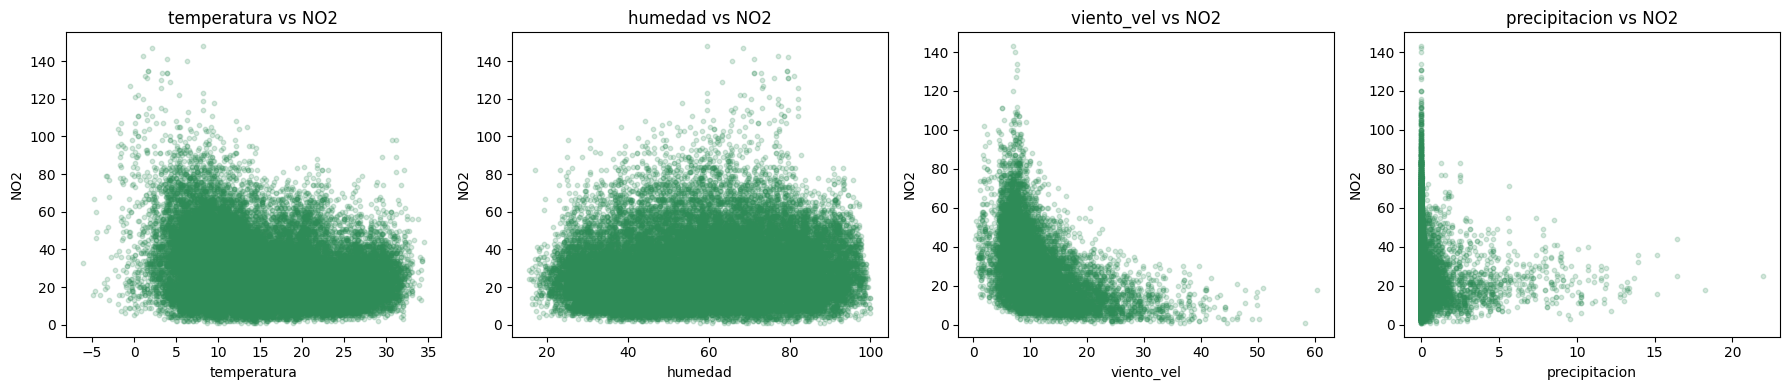

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

variables_meteo = ["temperatura", "humedad", "viento_vel", "precipitacion"]

for ax, variable in zip(axes, variables_meteo):
    ax.scatter(train[variable], train["no2"], alpha=0.2, s=10, color="seagreen")
    ax.set_xlabel(variable)
    ax.set_ylabel("NO2")
    ax.set_title(f"{variable} vs NO2")

plt.tight_layout()
plt.show()

In [12]:
correlacion_meteo = train[["no2"] + variables_meteo].corr()["no2"].drop("no2")
correlacion_meteo.sort_values(ascending=False)

humedad          0.133002
precipitacion   -0.083267
temperatura     -0.281485
viento_vel      -0.488114
Name: no2, dtype: float64

**¿Qué significa esto?** Aquí buscamos patrones conocidos del mundo real, para comprobar si los datos los reflejan:
- **Viento**: se espera una correlación **negativa** (más viento, "limpia" el aire, menos NO2 acumulado)
- **Precipitación**: también se espera negativa (la lluvia arrastra partículas y contaminantes)
- **Temperatura**: la relación es menos directa — en invierno hay más calefacción (sube NO2) pero también más ventilación en verano; puede no salir una relación lineal clara



## Resumen de correlaciones con el target

In [13]:
todas_las_features = variables_trafico + variables_meteo
resumen_correlacion = train[["no2"] + todas_las_features].corr()["no2"].drop("no2").sort_values(key=abs, ascending=False)

print("Features ordenadas por fuerza de relacion con NO2 (de mas a menos fuerte):")
resumen_correlacion

Features ordenadas por fuerza de relacion con NO2 (de mas a menos fuerte):


viento_vel        -0.488114
temperatura       -0.281485
vmed_mean         -0.157647
intensidad_mean    0.150378
ocupacion_mean     0.139435
humedad            0.133002
precipitacion     -0.083267
Name: no2, dtype: float64

## Conclusiones

### Sobre el target (NO2)

**La distribución no es simétrica, tiene "cola" hacia arriba (skew ≈ 1.2)**:  Con el NO2 pasa que la mayoría de los días tienen un nivel moderado, pero hay unos pocos días con picos muy altos de contaminación que "estiran" la distribución hacia la derecha. Esto es un aviso para el equipo de preprocesado: podría convenir aplicar una transformación (como el logaritmo) para que el target sea más fácil de modelar.

**Pocos outliers (2.3% de los días)**: de cada 100 días, solo unos 2 tienen un valor de NO2 realmente atípico. Es un porcentaje bajo, así que no parece que haya un problema grave de datos erróneos en el target.

**Más NO2 en día laboral que en fin de semana**: esto es la prueba más directa que tenemos de que el tráfico importa — entre semana, con más coches circulando para ir a trabajar, el NO2 sube. Es como comparar el ruido de una calle un lunes por la mañana frente a un domingo: se nota la diferencia.

### Sobre la relación con las features

**El viento es la variable más relacionada con el NO2 (correlación -0.49)**: cuando hace más viento, hay menos NO2 acumulado.

**El tráfico se relaciona con el NO2, pero más flojito de lo que esperábamos (~0.15)**: esto no significa que el tráfico no importe — ya vimos arriba que sí hay más NO2 en días laborales. Lo que pasa es que la relación no es "una línea recta perfecta" (por eso la correlación, que mide relaciones en línea recta, sale baja), sino algo más complicado. Es un poco como decir que "estudiar más siempre saca mejor nota" — es cierto en general, pero no es una relación perfecta y directa, hay muchos otros factores de por medio.

**La lluvia apenas se relaciona con el NO2**: aunque tiene el signo que esperábamos (negativo, la lluvia limpia un poco el aire), la relación es muy débil.



---

# Parte 4 · Correlaciones entre Features y Outliers


# Correlaciones entre Features y Outliers

Aquí ya no miramos el target, sino cómo se relacionan **las features entre sí** (para detectar multicolinealidad) y qué outliers hay en tráfico y meteorología.

Trabajamos siempre sobre `train.csv`.

**Qué vamos a ver:**
1. Heatmap de correlación entre features
2. Outliers en las variables de tráfico
3. Outliers en las variables de meteorología

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ruta = "../data_sample/"
train = pd.read_parquet(ruta + "train.parquet")

variables_trafico = ["intensidad_mean", "intensidad_max", "ocupacion_mean", "carga_mean", "vmed_mean", "vmed_max"]
variables_meteo = ["temperatura", "humedad", "viento_vel", "precipitacion"]
todas_las_features = variables_trafico + variables_meteo

print("Features a analizar:", todas_las_features)

Features a analizar: ['intensidad_mean', 'intensidad_max', 'ocupacion_mean', 'carga_mean', 'vmed_mean', 'vmed_max', 'temperatura', 'humedad', 'viento_vel', 'precipitacion']


## 1. Correlación entre features (multicolinealidad)



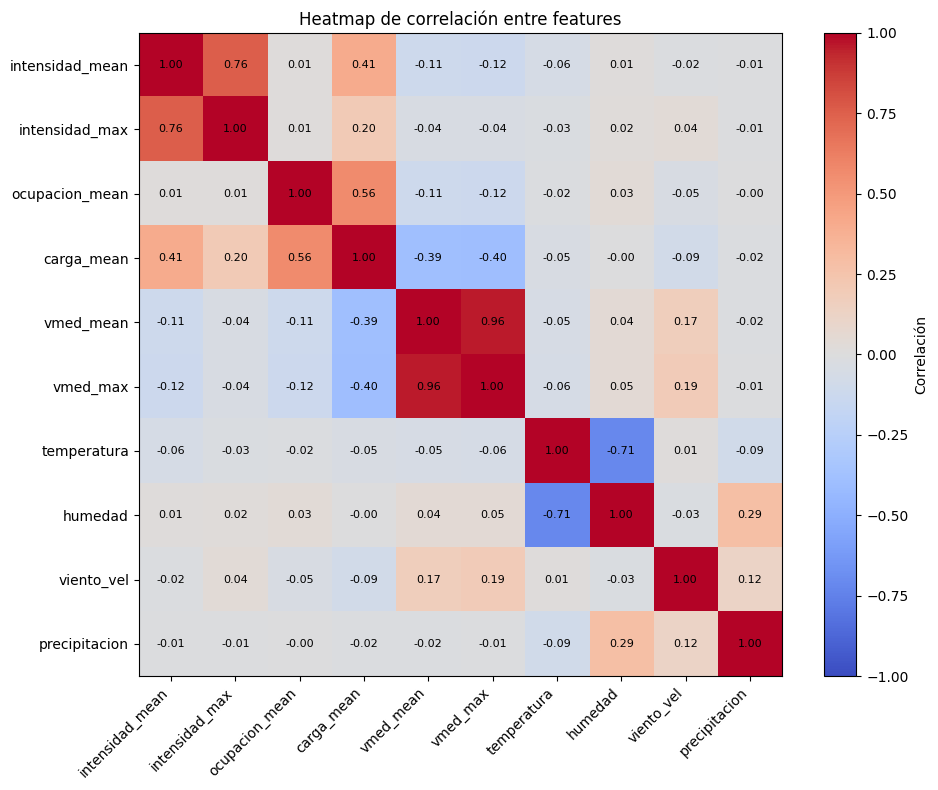

In [2]:
matriz_correlacion = train[todas_las_features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(matriz_correlacion, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlación")
plt.xticks(range(len(todas_las_features)), todas_las_features, rotation=45, ha="right")
plt.yticks(range(len(todas_las_features)), todas_las_features)

# Escribimos el numero de correlacion dentro de cada celda
for i in range(len(todas_las_features)):
    for j in range(len(todas_las_features)):
        valor = matriz_correlacion.iloc[i, j]
        plt.text(j, i, f"{valor:.2f}", ha="center", va="center", fontsize=8)

plt.title("Heatmap de correlación entre features")
plt.tight_layout()
plt.show()



**Qué buscar aquí**: las celdas con valores muy altos (por encima de 0.8 o 0.9, en positivo o negativo) fuera de la diagonal — esas son parejas de variables casi "redundantes". Es esperable, por ejemplo, que `intensidad_mean` e `intensidad_max` estén bastante correlacionadas entre sí (ambas miden "cuánto tráfico hay", una en promedio y otra en el pico).

In [3]:
# Buscamos automaticamente los pares de variables con correlacion muy alta 
pares_altos = []

for i in range(len(todas_las_features)):
    for j in range(i+1, len(todas_las_features)):
        valor = matriz_correlacion.iloc[i, j]
        if abs(valor) > 0.7:
            pares_altos.append({
                "variable_1": todas_las_features[i],
                "variable_2": todas_las_features[j],
                "correlacion": round(valor, 3)
            })

pd.DataFrame(pares_altos).sort_values("correlacion", key=abs, ascending=False)

,variable_1,variable_2,correlacion
1,vmed_mean,vmed_max,0.961
0,intensidad_mean,intensidad_max,0.755
2,temperatura,humedad,-0.715


**¿Qué significa esto?** En vez de buscar a ojo en el heatmap, aquí filtramos automáticamente solo los pares con correlación mayor a 0.7 (en valor absoluto) — el umbral habitual para considerar que hay multicolinealidad relevante. 

### Pairplot de variables seleccionadas

El heatmap nos da los números exactos, pero un pairplot nos deja **ver la forma** de esas relaciones (¿es una línea recta? ¿una nube sin forma? ¿una curva?). Seleccionamos algunas variables representativas (no las 10 a la vez, porque sería ilegible): una de tráfico (`intensidad_mean`), una de velocidad (`vmed_mean`), y las 3 de meteo principales.

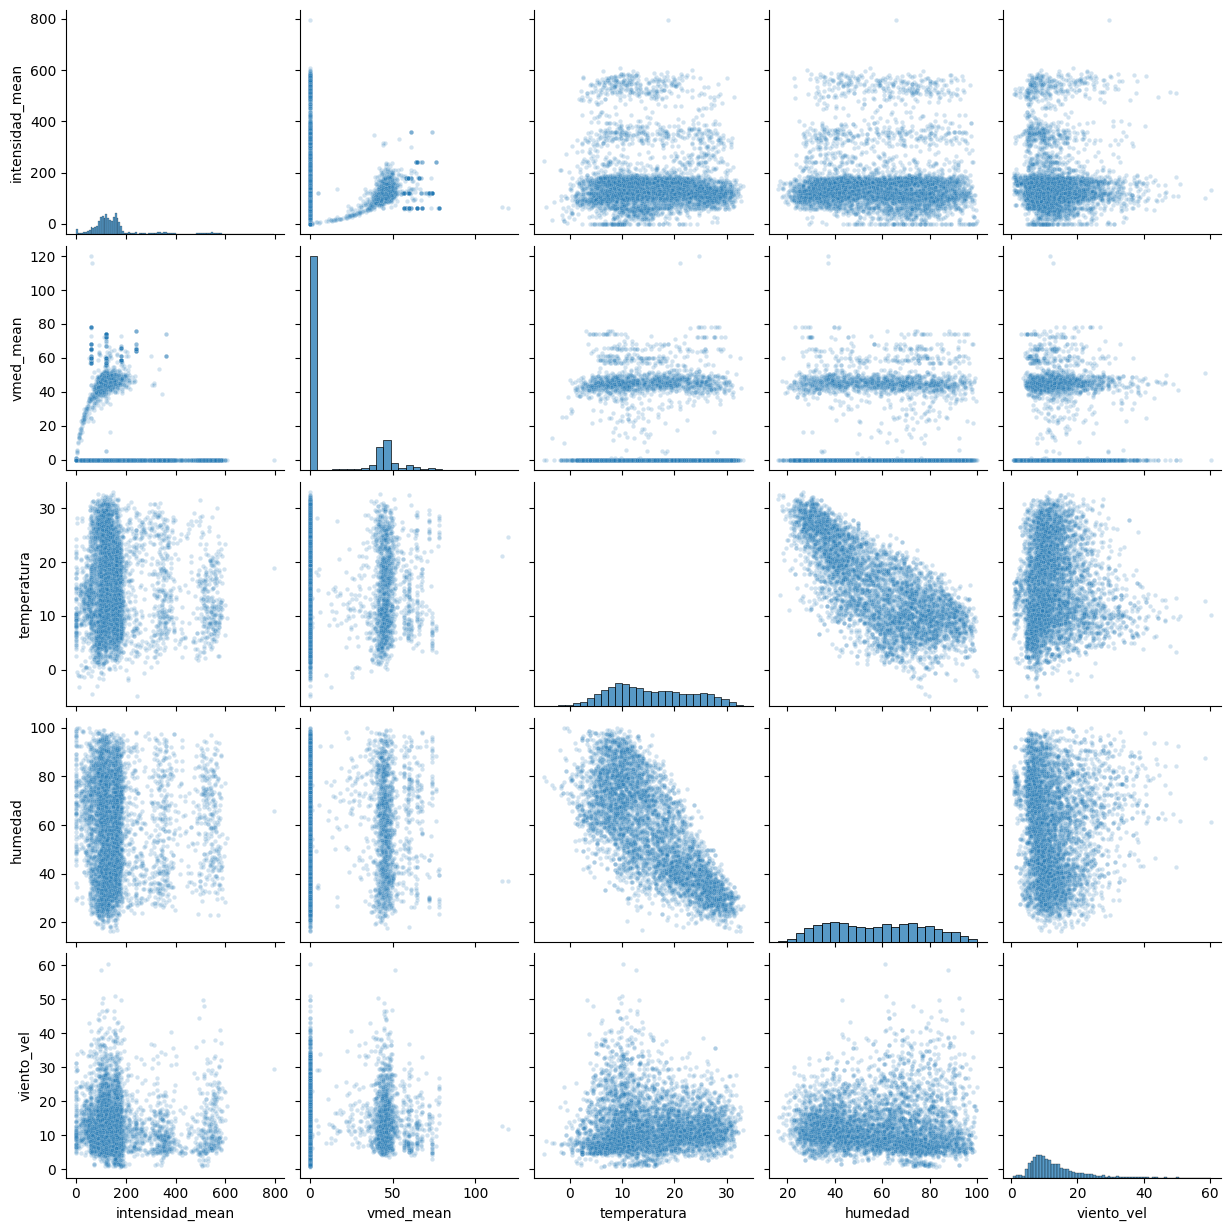

In [4]:
import seaborn as sns

variables_seleccionadas = ["intensidad_mean", "vmed_mean", "temperatura", "humedad", "viento_vel"]

sns.pairplot(train[variables_seleccionadas].dropna(), diag_kind="hist", plot_kws={"alpha": 0.2, "s": 10})
plt.show()

**¿Qué significa esto?** Cada casilla fuera de la diagonal es un scatter plot entre dos variables (como los que ya vimos, pero ahora cruzando features entre sí). La diagonal muestra un histograma de cada variable por separado (su distribución individual).

**Qué mirar aquí**: busca nubes de puntos con forma clara de línea (relación fuerte) frente a nubes redondas y dispersas sin forma (relación débil). Es la misma información que el heatmap, pero de un vistazo visual en vez de solo números.

## 2. Outliers en las variables de tráfico

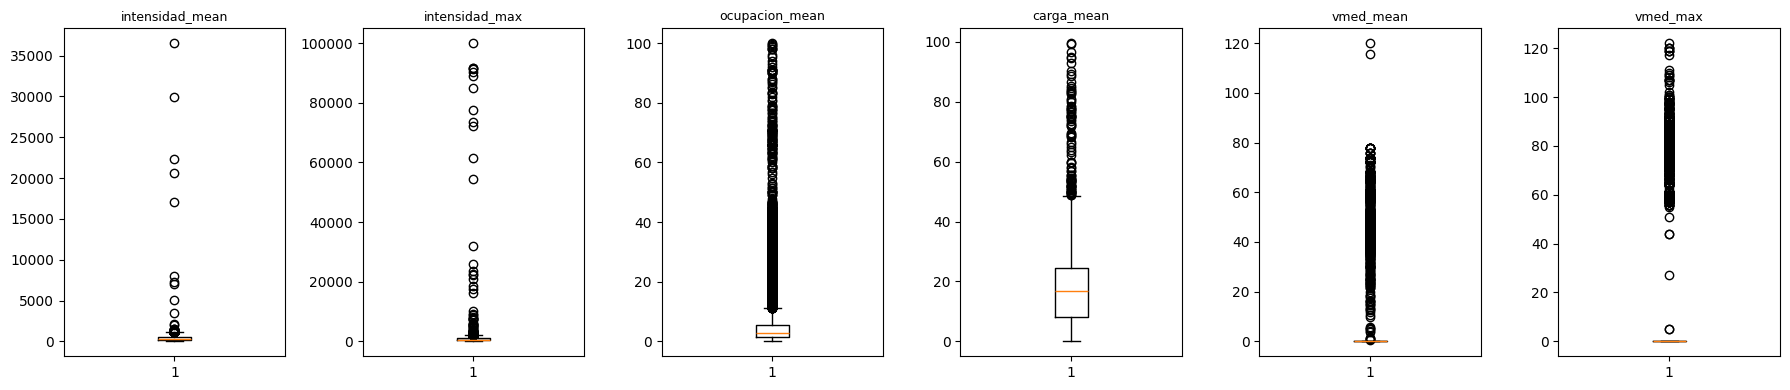

In [5]:
fig, axes = plt.subplots(1, len(variables_trafico), figsize=(18, 4))

for ax, variable in zip(axes, variables_trafico):
    ax.boxplot(train[variable].dropna())
    ax.set_title(variable, fontsize=9)

plt.tight_layout()
plt.show()

In [6]:
# Calculamos el porcentaje de outliers (metodo IQR) para cada variable de trafico
resumen_outliers_trafico = []

for variable in variables_trafico:
    datos = train[variable].dropna()
    q1, q3 = datos.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outliers = datos[(datos < limite_inf) | (datos > limite_sup)]

    resumen_outliers_trafico.append({
        "variable": variable,
        "num_outliers": len(outliers),
        "pct_outliers": round(len(outliers) / len(datos) * 100, 1)
    })

pd.DataFrame(resumen_outliers_trafico)

,variable,num_outliers,pct_outliers
0,intensidad_mean,242,1.0
1,intensidad_max,370,1.5
2,ocupacion_mean,1796,7.4
3,carga_mean,89,0.4
4,vmed_mean,1486,6.1
5,vmed_max,1486,6.1


## 3. Outliers en las variables de meteorología

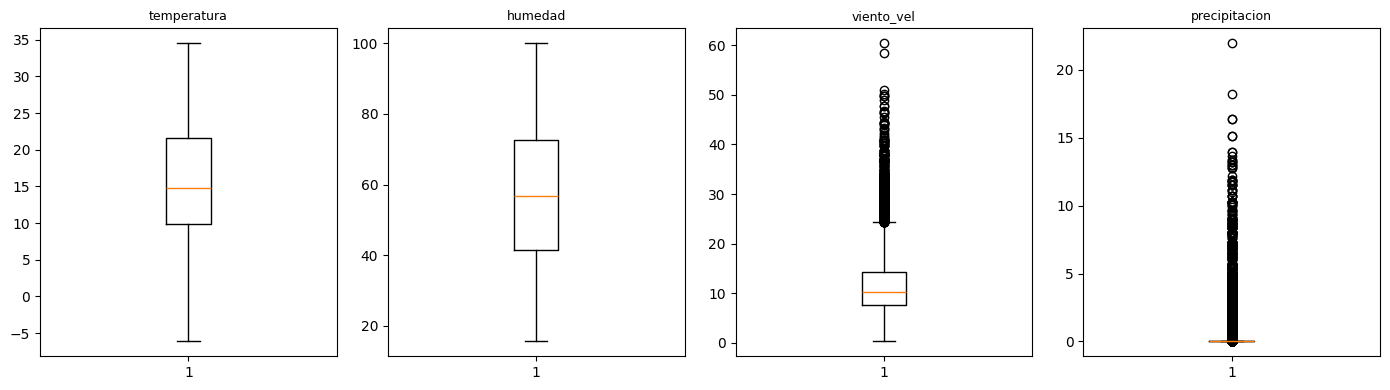

In [7]:
fig, axes = plt.subplots(1, len(variables_meteo), figsize=(14, 4))

for ax, variable in zip(axes, variables_meteo):
    ax.boxplot(train[variable].dropna())
    ax.set_title(variable, fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
resumen_outliers_meteo = []

for variable in variables_meteo:
    datos = train[variable].dropna()
    q1, q3 = datos.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outliers = datos[(datos < limite_inf) | (datos > limite_sup)]

    resumen_outliers_meteo.append({
        "variable": variable,
        "num_outliers": len(outliers),
        "pct_outliers": round(len(outliers) / len(datos) * 100, 1),
        "minimo": round(datos.min(), 1),
        "maximo": round(datos.max(), 1)
    })

pd.DataFrame(resumen_outliers_meteo)

,variable,num_outliers,pct_outliers,minimo,maximo
0,temperatura,0,0.0,-6.1,34.5
1,humedad,0,0.0,15.6,100.0
2,viento_vel,567,4.8,0.3,60.4
3,precipitacion,4316,23.1,0.0,22.0


## Conclusiones

### Sobre la correlación entre features (multicolinealidad)

**¿Qué estábamos mirando?** No si el tráfico o la meteo se relacionan con el NO2 (eso ya lo vimos en el notebook anterior), sino si **las features se parecen demasiado entre sí**.

**Lo que encontramos:**

- **`vmed_mean` y `vmed_max` van casi pegadas (correlación 0.96)**: la velocidad "normal" de un día y el pico más alto de velocidad de ese mismo día suben y bajan juntas casi siempre. Es como preguntar "¿cuánto mides?" y "¿cuánto mide tu cabeza más el resto del cuerpo?" — distintas preguntas, pero casi la misma respuesta. Darle las dos al modelo no aporta mucho más que darle solo una.

- **`intensidad_mean` e `intensidad_max` también van bastante juntas (0.76)**: lo mismo que arriba, aunque algo menos pegadas.

- **`temperatura` y `humedad` van en direcciones opuestas (-0.72)**: cuando sube la temperatura, baja la humedad (y al revés). Tiene sentido real: los días calurosos de Madrid suelen ser secos, los días húmedos suelen ser más fríos.

**¿Es esto un problema que hay que arreglar?** No es un error nuestro, es simplemente un aviso para el equipo de preprocesado: *"estas parejas de variables cuentan casi la misma historia, valorad si hace falta quedaros con las dos o solo con una"*.

**Sobre el pairplot**: confirma visualmente lo que ya decían los números — por ejemplo, la nube de puntos entre `temperatura` y `humedad` debería verse claramente descendente (a más temperatura, menos humedad), mientras que las nubes entre variables poco correlacionadas se ven más redondas y sin forma clara. El pairplot no añade información nueva sobre la que ya teníamos con el heatmap, pero ayuda a "verlo" en vez de solo leer un número, lo cual es útil para explicarlo en la presentación final del equipo.

### Sobre los outliers en las features

**¿Qué estábamos mirando?** Lo mismo que hicimos con el NO2 en el notebook anterior (método IQR), pero ahora aplicado a cada variable de tráfico y meteo por separado — cuántos días tienen un valor "raro" (muy alto o muy bajo) en cada una.

**Por qué revisamos también el mínimo y el máximo en meteo**: porque ya sabemos que esos datos venían con un error de escala que corregimos antes (el problema de los decimales perdidos). Mirar el mínimo/máximo nos ayuda a distinguir entre "un día real de mucho viento" y "un posible error de sensor que se nos haya colado".



---

# Parte 5 · Feature Engineering (Preprocesado)


# Feature Engineering - NO2

En este notebook construimos las features nuevas a partir del dataset final (`train.parquet`), 
pensadas para sacarle mas partido al modelo de regresion que prediga episodios de alta contaminacion.

**Que vamos a hacer:**
1. Cargar los datos desde `../data_sample/`
2. Split cronologico train_fe / test_fe (sin tocar el train/test del notebook 02)
3. Features temporales (ciclicas, estacion del anio, finde)
4. Lags y medias moviles de NO2 por estacion
5. Imputacion de meteo con flag de missing
6. Target encoding de estacion
7. Pipeline completo: fit en train_fe, transform en test_fe

Trabajamos siempre evitando fuga de datos (data leakage): todo lo que "aprende" de los datos 
(medianas, medias por estacion) se calcula solo con `train_fe`, nunca con `test_fe`.

## 1. Imports

Librerias necesarias para cargar los datos y montar el pipeline de feature engineering.

In [1]:
# Imports generales + para el pipeline de feature engineering
import glob
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin  # clases base para crear transformers custom compatibles con sklearn
from sklearn.pipeline import Pipeline  # para encadenar todos los pasos de FE en uno solo

## 2. Carga de datos

Leemos los ficheros parquet desde `../data_sample/`. Usamos `glob` con un patron comodin 
por si hay mas de un fichero parquet en esa carpeta.

In [2]:
# Recogemos el dataset completo.
df = pd.read_parquet('../data_sample/dataset_final.parquet') 

print(df.shape)
df.head()

(51001, 16)


,estacion,fecha,no2,temperatura,humedad,viento_vel,precipitacion,intensidad_mean,intensidad_max,ocupacion_mean,carga_mean,vmed_mean,vmed_max,tipo_elem_moda,distancia_meteo_km,distancia_trafico_km
0,4,2021-01-01,10,4.070833,NaN,NaN,NaN,388.155556,916.0,3.522222,21.722222,0.0,0.0,URB,0.0,0.06
1,4,2021-01-02,23,2.387500,NaN,NaN,NaN,516.344828,924.0,4.574713,28.563218,0.0,0.0,URB,0.0,0.06
2,4,2021-01-03,29,2.233333,NaN,NaN,NaN,476.076923,924.0,4.109890,26.329670,0.0,0.0,URB,0.0,0.06
3,4,2021-01-04,29,3.016667,NaN,NaN,NaN,677.088235,998.0,5.911765,37.044118,0.0,0.0,URB,0.0,0.06
4,4,2021-01-05,54,0.250000,NaN,NaN,NaN,588.095745,922.0,4.978723,32.202128,0.0,0.0,URB,0.0,0.06


## 3. Split cronologico: train_fe / test_fe

Este split es nuevo y va en paralelo al `train`/`test` aleatorio del notebook 02 (no lo sustituye).

**Por que un split por fecha y no aleatorio:** vamos a calcular lags y medias moviles de NO2 
(el valor de ayer, la media de los ultimos 7 dias...). Si el split fuera aleatorio, filas de 
fechas muy cercanas podrian caer una en train y otra en test, y un lag podria colarse informacion 
del futuro. Cortando por fecha, todo lo que hay en `test_fe` es estrictamente posterior a `train_fe`.

Usamos el percentil 80 de las fechas como corte, así queda aproximadamente un split 80/20.

In [3]:
# Fecha de corte: percentil 80 de las fechas disponibles (deja ~80/20)
fechas_unicas = sorted(df['fecha'].unique())
fecha_corte = fechas_unicas[int(len(fechas_unicas) * 0.8)]

train_fe = df[df['fecha'] < fecha_corte].copy()
test_fe = df[df['fecha'] >= fecha_corte].copy()

print(f"Fecha de corte: {fecha_corte}")
print(f"train_fe: {train_fe.shape[0]} filas ({train_fe['fecha'].min()} a {train_fe['fecha'].max()})")
print(f"test_fe:  {test_fe.shape[0]} filas ({test_fe['fecha'].min()} a {test_fe['fecha'].max()})")
print(f"Proporcion test_fe: {test_fe.shape[0] / df.shape[0]:.2%}")

Fecha de corte: 2023-09-25 00:00:00
train_fe: 40729 filas (2019-01-01 00:00:00 a 2023-09-24 00:00:00)
test_fe:  10272 filas (2023-09-25 00:00:00 a 2024-11-30 00:00:00)
Proporcion test_fe: 20.14%


## 4. Features temporales

Ampliamos el mes/dia de semana/finde que ya se vio en el notebook 03, con codificacion ciclica 
(seno/coseno) para que diciembre y enero queden "cerca" numericamente, y anadimos la estacion del anio.

Este transformer no aprende nada de los datos (no calcula ningun estadistico), solo deriva 
columnas nuevas a partir de la fecha. Por eso `fit` no hace nada.

In [4]:
class FeaturesTemporales(BaseEstimator, TransformerMixin):
    # No aprende nada de los datos (no hay estadisticos que calcular),
    # asi que fit no hace nada y solo devuelve self, como exige la interfaz de sklearn
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()  # copia defensiva, para no modificar el DataFrame original por referencia

        # Codificacion ciclica del mes: en vez de 1-12, usamos seno/coseno
        # para que diciembre (12) y enero (1) queden "cerca" en el espacio numerico,
        # en vez de parecer los extremos opuestos de una escala lineal
        X['mes_sin'] = np.sin(2 * np.pi * X['fecha'].dt.month / 12)
        X['mes_cos'] = np.cos(2 * np.pi * X['fecha'].dt.month / 12)

        # Mismo truco pero con el dia del anio (1-365), da mas resolucion que el mes
        X['dia_anio_sin'] = np.sin(2 * np.pi * X['fecha'].dt.dayofyear / 365)
        X['dia_anio_cos'] = np.cos(2 * np.pi * X['fecha'].dt.dayofyear / 365)

        # Flag de fin de semana: dayofweek 5 y 6 son sabado y domingo
        X['finde'] = X['fecha'].dt.dayofweek.isin([5, 6]).astype(int)

        # Estacion del anio a partir del mes, usando np.select para evaluar
        # varias condiciones a la vez (mas legible que anidar np.where)
        mes = X['fecha'].dt.month
        X['estacion_anio'] = np.select(
            [mes.isin([12, 1, 2]), mes.isin([3, 4, 5]), mes.isin([6, 7, 8])],  # condiciones en orden
            ['invierno', 'primavera', 'verano'],  # valor si se cumple cada condicion
            default='otonio'  # lo que no entra en ninguna de las anteriores (9, 10, 11)
        )
        return X

## 5. Lags y medias moviles de NO2

El NO2 tiene memoria: el valor de hoy se parece mucho al de ayer. Calculamos lags 
(1 dia y 7 dias atras) y medias moviles (3 y 7 dias), siempre agrupando por `estacion` 
para no mezclar el pasado de una estacion con el de otra.

Tampoco aprende nada de los datos: `shift`/`rolling` solo miran hacia atras dentro de cada fila, 
asi que es seguro calcularlo igual en train y en test.

In [5]:
class FeaturesLagNO2(BaseEstimator, TransformerMixin):
    def __init__(self, lags=(1, 7), ventanas_rolling=(3, 7)):
        self.lags = lags  # que lags calcular: 1 dia atras, 7 dias atras (mismo dia semana anterior)
        self.ventanas_rolling = ventanas_rolling  # tamanios de ventana para las medias moviles

    # Tampoco aprende nada: shift/rolling solo miran hacia atras dentro de cada fila,
    # asi que es seguro calcularlo igual en train y en test
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Ordenamos por estacion y fecha: imprescindible para que shift/rolling
        # avancen en el orden correcto dentro de cada estacion
        X = X.sort_values(['estacion', 'fecha']).copy()

        # Agrupamos por estacion para que cada lag/rolling se calcule
        # solo con los dias de esa misma estacion, sin mezclar con otras
        grupo = X.groupby('estacion')['no2']

        # Lags: el valor de no2 hace N dias, para esa misma estacion
        for lag in self.lags:
            X[f'no2_lag{lag}'] = grupo.shift(lag)

        # Rolling: media movil de los ultimos N dias, sin contar el dia actual
        # (por eso el shift(1) antes del rolling: evita que el dia de hoy
        # se use a si mismo para predecirse)
        for ventana in self.ventanas_rolling:
            X[f'no2_roll_mean_{ventana}'] = (
                X.groupby('estacion')['no2']
                .transform(
                    lambda serie: serie.shift(1).rolling(ventana).mean()
                )
            )

        return X

## 6. Imputacion de meteo con flag de missing

`viento_vel` y `precipitacion` tienen bastante missing (71% y 54%). En vez de eliminar filas, 
imputamos con la mediana y anadimos una columna flag que indica si el valor original era missing, 
por si esa ausencia es informativa en si misma.

Aqui si aprendemos algo de los datos (la mediana), y lo hacemos solo con `train_fe` en el `fit`.

In [6]:
class ImputadorMeteo(BaseEstimator, TransformerMixin):
    def __init__(self, columnas=('viento_vel', 'precipitacion')):
        self.columnas = columnas  # columnas meteo a imputar

    def fit(self, X, y=None):
        # Aqui si aprendemos algo de los datos: la mediana de cada columna,
        # pero calculada SOLO con X (que en la practica sera train_fe)
        self.medianas_ = {col: X[col].median() for col in self.columnas}
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columnas:
            # Flag que guarda si el valor original era missing, ANTES de imputar
            # (si no la creamos antes de fillna, perderiamos esta informacion)
            X[f'{col}_missing'] = X[col].isna().astype(int)

            # Rellenamos los NaN con la mediana aprendida en fit
            # (en test_fe usamos la mediana de train_fe, nunca la de test_fe)
            X[col] = X[col].fillna(self.medianas_[col])
        return X

## 7. Target encoding de estacion

Cada estacion tiene un nivel de contaminacion medio distinto (zonas de mucho trafico vs 
residenciales). Codificamos cada estacion por su NO2 medio historico, calculado solo con `train_fe`.

In [7]:
class TargetEncoderEstacion(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Media global de no2, por si aparece una estacion en test
        # que no estaba en train (no deberia pasar aqui, pero es una red de seguridad)
        self.media_global_ = X['no2'].mean()

        # Media de no2 por estacion, calculada solo con train_fe
        self.medias_estacion_ = X.groupby('estacion')['no2'].mean()
        return self

    def transform(self, X):
        X = X.copy()
        # Mapeamos cada estacion a su media aprendida en fit;
        # fillna cubre el caso de una estacion nueva no vista en train
        X['estacion_no2_mean'] = (
            X['estacion'].map(self.medias_estacion_).fillna(self.media_global_)
        )
        return X

## 8. Pipeline completo

Encadenamos los 4 transformers y aplicamos `fit_transform` solo en `train_fe` (aprende y transforma 
a la vez), y `transform` en `test_fe` (aplica lo ya aprendido, sin recalcular nada con datos de test).

Asi nos aseguramos de que no hay fuga de datos entre train_fe y test_fe en ningun paso.

In [8]:
# Encadenamos los 4 transformers en el orden en que queremos que se apliquen
pipeline_fe = Pipeline([
    ('temporales', FeaturesTemporales()),        # no aprende nada
    ('lags_no2', FeaturesLagNO2()),               # no aprende nada
    ('imputador_meteo', ImputadorMeteo()),        # aprende medianas de train
    ('target_encoder', TargetEncoderEstacion()),  # aprende medias de train
])

# fit_transform en train_fe: ajusta (fit) los transformers que aprenden algo
# usando solo train_fe, y a la vez transforma train_fe con ellos
train_fe_procesado = pipeline_fe.fit_transform(train_fe)

# transform en test_fe: aplica lo YA aprendido en train_fe (medianas, medias por estacion)
# sin volver a calcular nada con datos de test_fe -> asi evitamos el leakage
test_fe_procesado = pipeline_fe.transform(test_fe)

print(train_fe_procesado.shape, test_fe_procesado.shape)
train_fe_procesado.head()

(40729, 29) (10272, 29)


,estacion,fecha,no2,temperatura,humedad,viento_vel,precipitacion,intensidad_mean,intensidad_max,ocupacion_mean,...,dia_anio_cos,finde,estacion_anio,no2_lag1,no2_lag7,no2_roll_mean_3,no2_roll_mean_7,viento_vel_missing,precipitacion_missing,estacion_no2_mean
17277,4,2019-01-01,71,4.500000,NaN,11.022917,0.0,360.708333,653.0,1.270833,...,0.999852,0,invierno,NaN,NaN,16.666667,19.714286,1,1,30.419847
17278,4,2019-01-02,84,3.970833,NaN,11.022917,0.0,505.635417,890.0,2.843750,...,0.999407,0,invierno,71.0,NaN,11.666667,18.142857,1,1,30.419847
17279,4,2019-01-03,77,4.345833,NaN,11.022917,0.0,539.322917,887.0,3.479167,...,0.998667,0,invierno,84.0,NaN,14.000000,17.571429,1,1,30.419847
17280,4,2019-01-04,86,4.050000,NaN,11.022917,0.0,557.541667,923.0,3.229167,...,0.997630,0,invierno,77.0,NaN,17.333333,17.857143,1,1,30.419847
17281,4,2019-01-05,75,3.587500,NaN,11.022917,0.0,454.812500,794.0,2.770833,...,0.996298,1,invierno,86.0,NaN,23.333333,19.142857,1,1,30.419847


In [9]:
# Guardamos train_fe_procesado y test_fe_procesado en data_sample
# (las versiones YA pasadas por el pipeline, con las features nuevas incluidas)
train_fe_procesado.to_parquet('../data_sample/train_fe.parquet', index=False)
test_fe_procesado.to_parquet('../data_sample/test_fe.parquet', index=False)

print('train_fe guardado:', train_fe_procesado.shape)
print('test_fe guardado:', test_fe_procesado.shape)

train_fe guardado: (40729, 29)
test_fe guardado: (10272, 29)


## Conclusiones

- El split `train_fe`/`test_fe` es cronologico (corte en el percentil 80 de las fechas), 
  necesario para poder calcular lags y rolling de NO2 sin fuga de datos.
- Todas las estadisticas que "aprenden" de los datos (medianas de meteo, medias de NO2 por 
  estacion) se ajustan solo con `train_fe` y se aplican igual a `test_fe` con `transform`.
- Pendiente a revisar: los primeros dias de cada estacion en `train_fe` (y tambien el primer 
  dia de `test_fe`) se quedan con lags en NaN, porque no hay "dia anterior" disponible. 
  Hay que decidir si se imputan o se eliminan antes de entrenar el modelo.

---

# Parte 6 · Modelado, Optimización y Evaluación


# Modelado, optimización y evaluación final de NO₂

Este notebook desarrolla la fase de modelado del proyecto de predicción de contaminación atmosférica en Madrid.

El objetivo es predecir la concentración diaria de **NO₂** de cada estación utilizando variables meteorológicas, de tráfico, temporales y observaciones históricas del propio contaminante.

## Contenido

1. Carga de los conjuntos oficiales.
2. Preparación de las variables.
3. Definición de la métrica principal.
4. Construcción de un baseline temporal.
5. Comparación de modelos mediante validación cruzada temporal.
6. Optimización de hiperparámetros.
7. Selección del modelo final.
8. Evaluación única sobre el conjunto de test.
9. Interpretación de los coeficientes.
10. Guardado del pipeline y de sus metadatos.

## 1. Metodología y prevención de data leakage

Para respetar el orden temporal del problema, el dataset fue dividido previamente en:

- **Train:** desde enero de 2019 hasta septiembre de 2023.
- **Test:** desde septiembre de 2023 hasta noviembre de 2024.

El conjunto de test se mantiene reservado durante la comparación y optimización de modelos. Solo se utiliza después de seleccionar definitivamente el modelo y sus hiperparámetros.

Dentro de train se aplica una validación cruzada temporal. En cada fold, el modelo aprende con un periodo pasado y se valida sobre un periodo posterior.

Las operaciones que necesitan aprender parámetros, como la imputación, el escalado y el One-Hot Encoding, se incluyen dentro de un `Pipeline`. De esta forma se ajustan exclusivamente con los datos de entrenamiento de cada fold.

### Escenario de predicción

Se plantea una predicción diaria de un paso hacia adelante.

El modelo utiliza la observación anterior disponible de NO₂ para cada estación. En la gran mayoría de los casos esta observación corresponde al día anterior, aunque pueden existir algunos saltos temporales por ausencia de registros.

La variable `no2_lag1` representa esta observación anterior y constituye también el baseline principal del proyecto.

In [1]:
# Librerías generales
import json
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Herramientas de scikit-learn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    TimeSeriesSplit,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# El notebook puede ejecutarse desde la raíz del repositorio
# o desde la carpeta src/notebooks.
ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent

RUTA_DATOS = ROOT / "src" / "data_sample"
RUTA_MODELOS = ROOT / "src" / "models"
RUTA_IMAGENES = ROOT / "src" / "img"

RUTA_MODELOS.mkdir(parents=True, exist_ok=True)
RUTA_IMAGENES.mkdir(parents=True, exist_ok=True)

print("Directorio raíz:", ROOT)

Matplotlib is building the font cache; this may take a moment.


Directorio raíz: /Users/victoriabiancon/Desktop/ML_Contaminacion_Madrid


## 2. Carga de los conjuntos oficiales

Se cargan los archivos generados por el pipeline de feature engineering.

La variable objetivo es `no2`.

In [2]:
train = pd.read_parquet(
    RUTA_DATOS / "train_fe.parquet"
)

test = pd.read_parquet(
    RUTA_DATOS / "test_fe.parquet"
)

train = train.sort_values(
    ["fecha", "estacion"]
).copy()

test = test.sort_values(
    ["fecha", "estacion"]
).copy()

resumen_datos = pd.DataFrame({
    "conjunto": ["train", "test"],
    "filas": [len(train), len(test)],
    "columnas": [train.shape[1], test.shape[1]],
    "fecha_inicio": [
        train["fecha"].min(),
        test["fecha"].min(),
    ],
    "fecha_fin": [
        train["fecha"].max(),
        test["fecha"].max(),
    ],
})

resumen_datos

,conjunto,filas,columnas,fecha_inicio,fecha_fin
0,train,40729,29,2019-01-01,2023-09-24
1,test,10272,29,2023-09-25,2024-11-30


## 3. Restauración de valores ausentes

Durante el feature engineering, `viento_vel` y `precipitacion` fueron imputadas con la mediana del conjunto completo de train.

Para que los primeros folds temporales no utilicen indirectamente una estadística de periodos futuros, se recuperan los valores ausentes originales mediante las variables:

- `viento_vel_missing`
- `precipitacion_missing`

Posteriormente, el pipeline calculará la mediana utilizando exclusivamente el train correspondiente a cada fold.

In [3]:
for datos in [train, test]:
    datos.loc[
        datos["viento_vel_missing"] == 1,
        "viento_vel"
    ] = np.nan

    datos.loc[
        datos["precipitacion_missing"] == 1,
        "precipitacion"
    ] = np.nan

nulos_train = (
    train.isna()
    .sum()
    .loc[lambda serie: serie > 0]
    .sort_values(ascending=False)
    .rename("nulos_train")
)

nulos_test = (
    test.isna()
    .sum()
    .loc[lambda serie: serie > 0]
    .sort_values(ascending=False)
    .rename("nulos_test")
)

pd.concat(
    [nulos_train, nulos_test],
    axis=1
).fillna(0).astype(int)

,nulos_train,nulos_test
viento_vel,29055,7261
precipitacion,22122,5557
ocupacion_mean,16164,4685
intensidad_mean,16151,4681
intensidad_max,16151,4681
carga_mean,16151,4681
vmed_mean,16151,4681
vmed_max,16151,4681
tipo_elem_moda,16151,4681
temperatura,5785,11


## 4. Selección de las variables

Se eliminan las filas que no disponen de `no2_lag1`, ya que el escenario definido requiere una observación histórica anterior.

Se excluyen las siguientes columnas del modelo:

- `fecha`: se utiliza para ordenar los datos y crear los cortes temporales.
- `no2`: es la variable objetivo.
- `estacion_no2_mean`: fue calculada utilizando el target completo de train antes de la validación cruzada. Mantenerla podría introducir data leakage.

Las variables `estacion`, `tipo_elem_moda` y `estacion_anio` se tratan como categóricas.

In [4]:
filas_train_iniciales = len(train)
filas_test_iniciales = len(test)

train = (
    train.dropna(subset=["no2_lag1"])
    .reset_index(drop=True)
)

test = (
    test.dropna(subset=["no2_lag1"])
    .reset_index(drop=True)
)

cobertura_train = len(train) / filas_train_iniciales
cobertura_test = len(test) / filas_test_iniciales

columnas_excluidas = [
    "fecha",
    "no2",
    "estacion_no2_mean",
]

variables_categoricas = [
    "estacion",
    "tipo_elem_moda",
    "estacion_anio",
]

variables_numericas = [
    columna
    for columna in train.columns
    if columna not in columnas_excluidas
    and columna not in variables_categoricas
]

variables_modelo = (
    variables_numericas
    + variables_categoricas
)

print(f"Cobertura de train: {cobertura_train:.2%}")
print(f"Cobertura de test: {cobertura_test:.2%}")

print("\nNúmero de variables numéricas:")
print(len(variables_numericas))

print("\nNúmero de variables categóricas:")
print(len(variables_categoricas))

print("\nVariables excluidas:")
print(columnas_excluidas)

Cobertura de train: 99.94%
Cobertura de test: 99.77%

Número de variables numéricas:
23

Número de variables categóricas:
3

Variables excluidas:
['fecha', 'no2', 'estacion_no2_mean']


In [5]:
print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['temperatura', 'humedad', 'viento_vel', 'precipitacion', 'intensidad_mean', 'intensidad_max', 'ocupacion_mean', 'carga_mean', 'vmed_mean', 'vmed_max', 'distancia_meteo_km', 'distancia_trafico_km', 'mes_sin', 'mes_cos', 'dia_anio_sin', 'dia_anio_cos', 'finde', 'no2_lag1', 'no2_lag7', 'no2_roll_mean_3', 'no2_roll_mean_7', 'viento_vel_missing', 'precipitacion_missing']

Variables categóricas:
['estacion', 'tipo_elem_moda', 'estacion_anio']


## 5. Métrica principal

La métrica principal seleccionada es el **MAE — Mean Absolute Error**.

El MAE expresa el error medio en las mismas unidades de la variable objetivo, es decir, en aproximadamente µg/m³ de NO₂. Además, es menos sensible que el RMSE a días puntuales con errores extremadamente altos.

Como métricas secundarias se utilizan:

- **RMSE:** penaliza con mayor intensidad los errores grandes.
- **R²:** indica qué proporción de la variabilidad del NO₂ es explicada por el modelo.

In [6]:
def calcular_metricas(y_real, y_pred):
    return {
        "MAE": mean_absolute_error(
            y_real,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_real,
                y_pred
            )
        ),
        "R2": r2_score(
            y_real,
            y_pred
        ),
    }

## 6. Pipelines de preprocesamiento

Para los modelos lineales:

1. Los valores numéricos ausentes se imputan con la mediana.
2. Las variables numéricas se estandarizan.
3. Las variables categóricas se imputan con la moda.
4. Las categorías se transforman mediante One-Hot Encoding.

Para los modelos basados en árboles no se aplica escalado, ya que su funcionamiento no depende de la escala de las variables.

In [7]:
preprocesador_lineal = ColumnTransformer([
    (
        "numericas",
        Pipeline([
            (
                "imputacion",
                SimpleImputer(strategy="median")
            ),
            (
                "escalado",
                StandardScaler()
            ),
        ]),
        variables_numericas,
    ),
    (
        "categoricas",
        Pipeline([
            (
                "imputacion",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            ),
        ]),
        variables_categoricas,
    ),
])

preprocesador_arboles = ColumnTransformer([
    (
        "numericas",
        SimpleImputer(strategy="median"),
        variables_numericas,
    ),
    (
        "categoricas",
        Pipeline([
            (
                "imputacion",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            ),
        ]),
        variables_categoricas,
    ),
])

## 7. Validación cruzada temporal

Se utilizan cuatro folds temporales.

Las fechas se separan antes de seleccionar las filas para garantizar que todas las estaciones de un mismo día permanezcan en el mismo fold.

En cada iteración:

- El train contiene solamente fechas anteriores.
- La validación contiene un periodo posterior.
- Ningún dato futuro se utiliza para entrenar el modelo.

In [8]:
fechas_train_disponibles = np.array(
    sorted(train["fecha"].unique())
)

tscv = TimeSeriesSplit(n_splits=4)

folds_temporales = []

for idx_train_fecha, idx_validacion_fecha in tscv.split(
    fechas_train_disponibles
):
    fechas_fold_train = fechas_train_disponibles[
        idx_train_fecha
    ]

    fechas_fold_validacion = fechas_train_disponibles[
        idx_validacion_fecha
    ]

    indices_train = np.flatnonzero(
        train["fecha"]
        .isin(fechas_fold_train)
        .to_numpy()
    )

    indices_validacion = np.flatnonzero(
        train["fecha"]
        .isin(fechas_fold_validacion)
        .to_numpy()
    )

    folds_temporales.append(
        (indices_train, indices_validacion)
    )

periodos_folds = []

for numero, (
    indices_train,
    indices_validacion
) in enumerate(folds_temporales, start=1):
    periodos_folds.append({
        "fold": numero,
        "train_inicio": train.loc[
            indices_train,
            "fecha"
        ].min(),
        "train_fin": train.loc[
            indices_train,
            "fecha"
        ].max(),
        "validacion_inicio": train.loc[
            indices_validacion,
            "fecha"
        ].min(),
        "validacion_fin": train.loc[
            indices_validacion,
            "fecha"
        ].max(),
        "filas_train": len(indices_train),
        "filas_validacion": len(indices_validacion),
    })

pd.DataFrame(periodos_folds)

,fold,train_inicio,train_fin,validacion_inicio,validacion_fin,filas_train,filas_validacion
0,1,2019-01-02,2019-12-14,2019-12-15,2020-11-23,8237,8177
1,2,2019-01-02,2020-11-23,2020-11-24,2021-11-03,16414,8183
2,3,2019-01-02,2021-11-03,2021-11-04,2022-10-14,24597,7983
3,4,2019-01-02,2022-10-14,2022-10-15,2023-09-24,32580,8125


## 8. Baseline y comparación inicial de modelos

El baseline consiste en utilizar como predicción la última observación disponible de NO₂ de la misma estación.

Se comparan tres familias de modelos:

- **Ridge:** modelo lineal con regularización L2.
- **Random Forest:** conjunto de árboles de decisión.
- **HistGradientBoosting:** modelo de boosting basado en árboles.

El baseline permite comprobar si los modelos aportan realmente valor frente a una regla temporal sencilla.

In [9]:
modelos_iniciales = {
    "Ridge": Pipeline([
        (
            "preprocesado",
            preprocesador_lineal
        ),
        (
            "modelo",
            Ridge(alpha=10.0)
        ),
    ]),

    "Random Forest": Pipeline([
        (
            "preprocesado",
            preprocesador_arboles
        ),
        (
            "modelo",
            RandomForestRegressor(
                n_estimators=100,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        ),
    ]),

    "HistGradientBoosting": Pipeline([
        (
            "preprocesado",
            preprocesador_arboles
        ),
        (
            "modelo",
            HistGradientBoostingRegressor(
                max_iter=200,
                learning_rate=0.05,
                random_state=42
            )
        ),
    ]),
}

In [10]:
resultados_iniciales = []

for fold, (
    indices_train,
    indices_validacion
) in enumerate(folds_temporales, start=1):

    datos_train_fold = train.loc[
        indices_train
    ].copy()

    datos_validacion_fold = train.loc[
        indices_validacion
    ].copy()

    X_train_fold = datos_train_fold[
        variables_modelo
    ]

    y_train_fold = datos_train_fold["no2"]

    X_validacion_fold = datos_validacion_fold[
        variables_modelo
    ]

    y_validacion_fold = datos_validacion_fold["no2"]

    pred_baseline = datos_validacion_fold[
        "no2_lag1"
    ]

    resultados_iniciales.append({
        "fold": fold,
        "modelo": "Baseline lag1",
        **calcular_metricas(
            y_validacion_fold,
            pred_baseline
        ),
        "tiempo_segundos": 0.0,
    })

    for nombre, modelo_base in modelos_iniciales.items():
        modelo = clone(modelo_base)

        inicio = time.time()

        modelo.fit(
            X_train_fold,
            y_train_fold
        )

        predicciones = modelo.predict(
            X_validacion_fold
        )

        resultados_iniciales.append({
            "fold": fold,
            "modelo": nombre,
            **calcular_metricas(
                y_validacion_fold,
                predicciones
            ),
            "tiempo_segundos": time.time() - inicio,
        })

resultados_iniciales_df = pd.DataFrame(
    resultados_iniciales
)

resultados_iniciales_df

,fold,modelo,MAE,RMSE,R2,tiempo_segundos
0,1,Baseline lag1,7.652073,10.735818,0.660932,0.000000
1,1,Ridge,7.121334,9.312016,0.744904,0.055090
2,1,Random Forest,7.432090,9.768266,0.719294,1.782439
3,1,HistGradientBoosting,7.838277,10.277545,0.689261,6.157058
4,2,Baseline lag1,8.109006,10.785466,0.579341,0.000000
5,2,Ridge,7.235294,9.666579,0.662092,0.114799
6,2,Random Forest,7.355971,10.003936,0.638095,4.447368
7,2,HistGradientBoosting,7.406889,10.199248,0.623826,7.847394
8,3,Baseline lag1,8.423024,11.412423,0.473024,0.000000
9,3,Ridge,7.031565,9.453450,0.638410,0.157117


In [11]:
resumen_inicial = (
    resultados_iniciales_df
    .groupby("modelo")
    .agg(
        MAE_medio=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_medio=("RMSE", "mean"),
        R2_medio=("R2", "mean"),
        tiempo_medio=(
            "tiempo_segundos",
            "mean"
        ),
    )
    .sort_values("MAE_medio")
    .reset_index()
)

resumen_inicial

,modelo,MAE_medio,MAE_std,RMSE_medio,R2_medio,tiempo_medio
0,Ridge,7.051028,0.177531,9.310807,0.656566,0.129354
1,Random Forest,7.221886,0.205647,9.606702,0.634800,4.872430
2,HistGradientBoosting,7.233801,0.499985,9.624946,0.637931,6.239453
3,Baseline lag1,7.953041,0.383581,10.809730,0.534990,0.000000


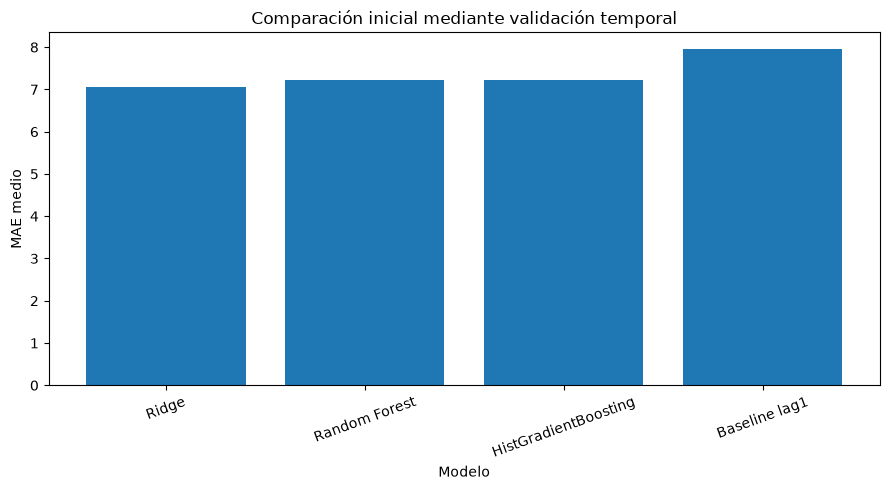

In [12]:
figura, eje = plt.subplots(
    figsize=(9, 5)
)

eje.bar(
    resumen_inicial["modelo"],
    resumen_inicial["MAE_medio"]
)

eje.set_title(
    "Comparación inicial mediante validación temporal"
)
eje.set_ylabel("MAE medio")
eje.set_xlabel("Modelo")
eje.tick_params(
    axis="x",
    rotation=20
)

figura.tight_layout()

figura.savefig(
    RUTA_IMAGENES
    / "comparacion_inicial_modelos.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Selección de candidatos

En la comparación inicial, Ridge obtiene el menor MAE medio, la menor variabilidad entre folds y el menor tiempo de entrenamiento.

HistGradientBoosting se mantiene como segundo candidato por su capacidad para capturar relaciones no lineales.

Random Forest no se optimiza porque obtiene un resultado ligeramente inferior al boosting y presenta un mayor coste computacional.

## 9. Optimización de Ridge

El parámetro `alpha` controla la intensidad de la regularización:

- Valores pequeños producen un comportamiento similar a una regresión lineal sin regularización.
- Valores elevados reducen con mayor intensidad los coeficientes.

La búsqueda se realiza utilizando exclusivamente los folds temporales de train y optimizando el MAE.

In [13]:
pipeline_ridge = Pipeline([
    (
        "preprocesado",
        preprocesador_lineal
    ),
    (
        "modelo",
        Ridge()
    ),
])

parametros_ridge = {
    "modelo__alpha": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100,
        300,
        1000,
        3000,
        10000,
        30000,
        100000,
    ]
}

X_desarrollo = train[variables_modelo]
y_desarrollo = train["no2"]

busqueda_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=parametros_ridge,
    scoring="neg_mean_absolute_error",
    cv=folds_temporales,
    n_jobs=-1,
    return_train_score=True,
)

busqueda_ridge.fit(
    X_desarrollo,
    y_desarrollo
)

resultados_ridge = pd.DataFrame(
    busqueda_ridge.cv_results_
)

resultados_ridge["MAE_train"] = (
    -resultados_ridge["mean_train_score"]
)

resultados_ridge["MAE_validacion"] = (
    -resultados_ridge["mean_test_score"]
)

resumen_ridge = (
    resultados_ridge[
        [
            "param_modelo__alpha",
            "MAE_train",
            "MAE_validacion",
            "std_test_score",
        ]
    ]
    .sort_values("MAE_validacion")
    .reset_index(drop=True)
)

resumen_ridge

,param_modelo__alpha,MAE_train,MAE_validacion,std_test_score
0,1000.000,7.444700,6.944956,0.121091
1,300.000,7.381690,6.949321,0.111724
2,100.000,7.360810,6.988354,0.125191
3,10.000,7.357790,7.051028,0.153746
4,3000.000,7.609182,7.055864,0.235553
5,1.000,7.359000,7.062749,0.160289
6,0.100,7.359127,7.063992,0.160965
7,0.010,7.359142,7.064116,0.161032
8,0.001,7.359144,7.064128,0.161039
9,10000.000,8.130311,7.541709,0.707968


In [14]:
mejor_alpha = busqueda_ridge.best_params_[
    "modelo__alpha"
]

mejor_mae_ridge = -busqueda_ridge.best_score_

print("Mejor alpha:", mejor_alpha)
print(
    "Mejor MAE medio de validación:",
    round(mejor_mae_ridge, 3)
)

Mejor alpha: 1000
Mejor MAE medio de validación: 6.945


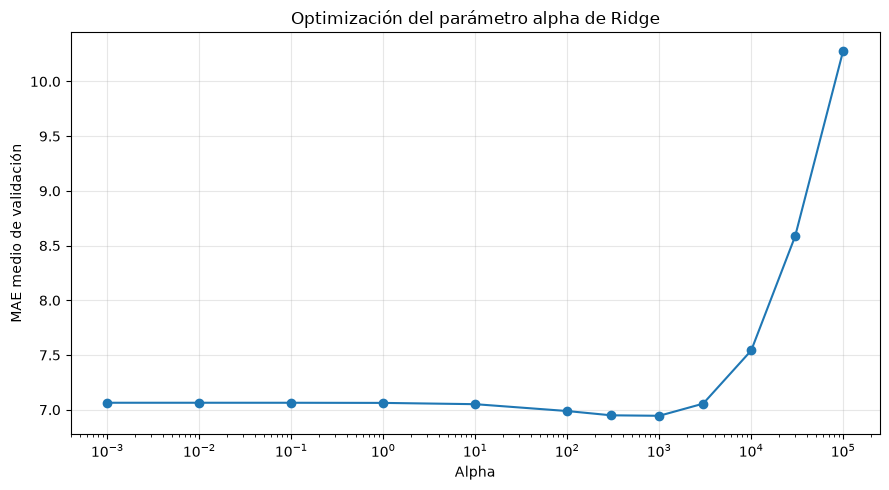

In [15]:
resultados_ridge_ordenados = (
    resumen_ridge
    .sort_values("param_modelo__alpha")
)

figura, eje = plt.subplots(
    figsize=(9, 5)
)

eje.plot(
    resultados_ridge_ordenados[
        "param_modelo__alpha"
    ],
    resultados_ridge_ordenados[
        "MAE_validacion"
    ],
    marker="o"
)

eje.set_xscale("log")
eje.set_title(
    "Optimización del parámetro alpha de Ridge"
)
eje.set_xlabel("Alpha")
eje.set_ylabel("MAE medio de validación")
eje.grid(True, alpha=0.3)

figura.tight_layout()

figura.savefig(
    RUTA_IMAGENES
    / "optimizacion_alpha_ridge.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

El mejor resultado se obtiene con `alpha = 1000`.

Los valores superiores comienzan a empeorar el MAE, por lo que el resultado no se encuentra simplemente en el límite de la búsqueda. La regularización elevada ayuda a controlar los coeficientes de un conjunto de variables correlacionadas y transformadas mediante One-Hot Encoding.

## 10. Optimización de HistGradientBoosting

Se utiliza `RandomizedSearchCV` para explorar una selección representativa de combinaciones sin ejecutar una búsqueda exhaustiva excesivamente costosa.

Se optimizan:

- Tasa de aprendizaje.
- Número máximo de iteraciones.
- Número máximo de hojas.
- Número mínimo de muestras por hoja.
- Regularización L2.

In [16]:
pipeline_hgb = Pipeline([
    (
        "preprocesado",
        preprocesador_arboles
    ),
    (
        "modelo",
        HistGradientBoostingRegressor(
            random_state=42
        )
    ),
])

parametros_hgb = {
    "modelo__learning_rate": [
        0.03,
        0.05,
        0.08,
        0.1,
    ],
    "modelo__max_iter": [
        100,
        200,
        300,
    ],
    "modelo__max_leaf_nodes": [
        15,
        31,
        63,
    ],
    "modelo__min_samples_leaf": [
        20,
        40,
        80,
    ],
    "modelo__l2_regularization": [
        0.0,
        0.1,
        1.0,
        10.0,
    ],
}

busqueda_hgb = RandomizedSearchCV(
    estimator=pipeline_hgb,
    param_distributions=parametros_hgb,
    n_iter=12,
    scoring="neg_mean_absolute_error",
    cv=folds_temporales,
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
)

busqueda_hgb.fit(
    X_desarrollo,
    y_desarrollo
)

resultados_hgb = pd.DataFrame(
    busqueda_hgb.cv_results_
)

resultados_hgb["MAE_train"] = (
    -resultados_hgb["mean_train_score"]
)

resultados_hgb["MAE_validacion"] = (
    -resultados_hgb["mean_test_score"]
)

columnas_hgb = [
    "param_modelo__learning_rate",
    "param_modelo__max_iter",
    "param_modelo__max_leaf_nodes",
    "param_modelo__min_samples_leaf",
    "param_modelo__l2_regularization",
    "MAE_train",
    "MAE_validacion",
    "std_test_score",
]

resumen_hgb = (
    resultados_hgb[columnas_hgb]
    .sort_values("MAE_validacion")
    .reset_index(drop=True)
)

resumen_hgb

,param_modelo__learning_rate,param_modelo__max_iter,param_modelo__max_leaf_nodes,param_modelo__min_samples_leaf,param_modelo__l2_regularization,MAE_train,MAE_validacion,std_test_score
0,0.05,100,31,20,0.0,5.559979,7.061906,0.365691
1,0.05,300,15,20,0.1,5.213431,7.171475,0.395770
2,0.05,300,15,40,0.1,5.277792,7.173344,0.394135
3,0.05,200,31,40,0.1,4.832000,7.222069,0.413709
4,0.08,100,31,80,1.0,5.225921,7.224117,0.427827
5,0.10,200,15,20,10.0,5.022151,7.273264,0.477619
6,0.10,300,15,40,10.0,4.665753,7.369769,0.493058
7,0.08,300,15,20,0.1,4.725083,7.377565,0.533770
8,0.08,200,31,80,10.0,4.545677,7.410213,0.475400
9,0.10,100,63,20,0.1,3.887886,7.445055,0.399729


In [17]:
print("Mejores parámetros de HistGradientBoosting:")

for parametro, valor in busqueda_hgb.best_params_.items():
    print(parametro, ":", valor)

print(
    "\nMejor MAE medio de validación:",
    round(-busqueda_hgb.best_score_, 3)
)

Mejores parámetros de HistGradientBoosting:
modelo__min_samples_leaf : 20
modelo__max_leaf_nodes : 31
modelo__max_iter : 100
modelo__learning_rate : 0.05
modelo__l2_regularization : 0.0

Mejor MAE medio de validación: 7.062


## 11. Comparación final antes del test

Se comparan nuevamente:

- Baseline temporal.
- Ridge optimizado.
- HistGradientBoosting optimizado.

Esta comparación continúa utilizando exclusivamente train. Después de este paso, el modelo y sus hiperparámetros quedan bloqueados.

In [18]:
ridge_optimizado = Pipeline([
    (
        "preprocesado",
        preprocesador_lineal
    ),
    (
        "modelo",
        Ridge(alpha=1000)
    ),
])

hgb_optimizado = Pipeline([
    (
        "preprocesado",
        preprocesador_arboles
    ),
    (
        "modelo",
        HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=100,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            l2_regularization=0.0,
            random_state=42
        )
    ),
])

modelos_finalistas = {
    "Ridge optimizado": ridge_optimizado,
    "HistGradientBoosting optimizado": hgb_optimizado,
}

In [19]:
resultados_finalistas = []

for fold, (
    indices_train,
    indices_validacion
) in enumerate(folds_temporales, start=1):

    datos_train_fold = train.loc[
        indices_train
    ].copy()

    datos_validacion_fold = train.loc[
        indices_validacion
    ].copy()

    X_train_fold = datos_train_fold[
        variables_modelo
    ]

    y_train_fold = datos_train_fold["no2"]

    X_validacion_fold = datos_validacion_fold[
        variables_modelo
    ]

    y_validacion_fold = datos_validacion_fold["no2"]

    pred_baseline = datos_validacion_fold[
        "no2_lag1"
    ]

    resultados_finalistas.append({
        "fold": fold,
        "modelo": "Baseline lag1",
        **calcular_metricas(
            y_validacion_fold,
            pred_baseline
        ),
        "tiempo_segundos": 0.0,
    })

    for nombre, modelo_base in modelos_finalistas.items():
        modelo = clone(modelo_base)

        inicio = time.time()

        modelo.fit(
            X_train_fold,
            y_train_fold
        )

        predicciones = modelo.predict(
            X_validacion_fold
        )

        resultados_finalistas.append({
            "fold": fold,
            "modelo": nombre,
            **calcular_metricas(
                y_validacion_fold,
                predicciones
            ),
            "tiempo_segundos": time.time() - inicio,
        })

resultados_finalistas_df = pd.DataFrame(
    resultados_finalistas
)

resultados_finalistas_df

,fold,modelo,MAE,RMSE,R2,tiempo_segundos
0,1,Baseline lag1,7.652073,10.735818,0.660932,0.000000
1,1,Ridge optimizado,7.017186,9.253808,0.748083,0.074777
2,1,HistGradientBoosting optimizado,7.558952,9.824091,0.716077,2.390999
3,2,Baseline lag1,8.109006,10.785466,0.579341,0.000000
4,2,Ridge optimizado,7.066408,9.563241,0.669278,0.111524
5,2,HistGradientBoosting optimizado,7.239083,9.971528,0.640436,2.780782
6,3,Baseline lag1,8.423024,11.412423,0.473024,0.000000
7,3,Ridge optimizado,6.947934,9.311366,0.649198,0.152196
8,3,HistGradientBoosting optimizado,6.845592,9.118952,0.663546,2.858637
9,4,Baseline lag1,7.628062,10.305213,0.426664,0.000000


In [20]:
resumen_finalistas = (
    resultados_finalistas_df
    .groupby("modelo")
    .agg(
        MAE_medio=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_medio=("RMSE", "mean"),
        R2_medio=("R2", "mean"),
        tiempo_medio=(
            "tiempo_segundos",
            "mean"
        ),
    )
    .sort_values("MAE_medio")
    .reset_index()
)

resumen_finalistas

,modelo,MAE_medio,MAE_std,RMSE_medio,R2_medio,tiempo_medio
0,Ridge optimizado,6.944956,0.139824,9.216208,0.663625,0.133200
1,HistGradientBoosting optimizado,7.061906,0.422264,9.390738,0.654065,2.854279
2,Baseline lag1,7.953041,0.383581,10.809730,0.534990,0.000000


### Modelo seleccionado

Se selecciona **Ridge con `alpha = 1000`** porque:

- Obtiene el menor MAE medio.
- Presenta la menor variabilidad entre folds temporales.
- Es considerablemente más rápido.
- Es más sencillo de interpretar.
- No muestra la misma diferencia entre train y validación observada en el modelo de boosting.

Una vez realizada esta selección, no se modifican el modelo, las variables ni los hiperparámetros utilizando información del conjunto de test.

## 12. Evaluación final sobre test

El pipeline Ridge se entrena con todo el conjunto de desarrollo y se evalúa sobre el test reservado.

Esta evaluación representa el rendimiento esperado sobre datos futuros no utilizados durante la selección del modelo.

In [21]:
X_train_final = train[variables_modelo]
y_train_final = train["no2"]

X_test_final = test[variables_modelo]
y_test_final = test["no2"]

modelo_final = clone(
    ridge_optimizado
)

modelo_final.fit(
    X_train_final,
    y_train_final
)

predicciones_test = modelo_final.predict(
    X_test_final
)

predicciones_baseline_test = test[
    "no2_lag1"
]

metricas_modelo_test = calcular_metricas(
    y_test_final,
    predicciones_test
)

metricas_baseline_test = calcular_metricas(
    y_test_final,
    predicciones_baseline_test
)

mejora_mae_porcentaje = (
    (
        metricas_baseline_test["MAE"]
        - metricas_modelo_test["MAE"]
    )
    / metricas_baseline_test["MAE"]
    * 100
)

resultados_test = pd.DataFrame([
    {
        "modelo": "Baseline lag1",
        **metricas_baseline_test,
    },
    {
        "modelo": "Ridge alpha=1000",
        **metricas_modelo_test,
    },
])

resultados_test

,modelo,MAE,RMSE,R2
0,Baseline lag1,7.216335,9.811211,0.589171
1,Ridge alpha=1000,6.959357,8.998921,0.654382


In [22]:
print(
    "Mejora del MAE frente al baseline:"
)

print(
    f"{mejora_mae_porcentaje:.2f}%"
)

print(
    "\nCobertura del conjunto de test:"
)

print(
    f"{cobertura_test:.2%}"
)

Mejora del MAE frente al baseline:
3.56%

Cobertura del conjunto de test:
99.77%


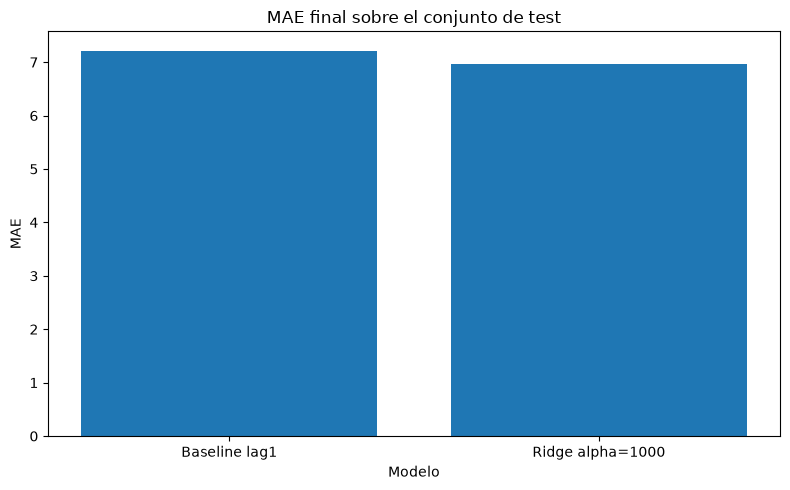

In [23]:
figura, eje = plt.subplots(
    figsize=(8, 5)
)

eje.bar(
    resultados_test["modelo"],
    resultados_test["MAE"]
)

eje.set_title(
    "MAE final sobre el conjunto de test"
)
eje.set_ylabel("MAE")
eje.set_xlabel("Modelo")

figura.tight_layout()

figura.savefig(
    RUTA_IMAGENES
    / "resultados_finales_test.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Lectura de los resultados

El MAE del modelo final se mantiene muy próximo al obtenido durante la validación temporal. Esto indica que el rendimiento estimado durante el desarrollo se reproduce sobre el periodo futuro reservado.

El baseline obtiene un resultado especialmente competitivo en test porque existe una fuerte persistencia temporal en la concentración de NO₂. Aun así, Ridge consigue reducir adicionalmente el error utilizando el resto de variables disponibles.

## 13. Análisis de los errores

Se estudia la distribución de los residuos y la relación entre los valores reales y las predicciones.

El residuo se define como:

`valor real - predicción`

In [24]:
analisis_test = test[
    [
        "fecha",
        "estacion",
        "no2",
    ]
].copy()

analisis_test["prediccion"] = (
    predicciones_test
)

analisis_test["residuo"] = (
    analisis_test["no2"]
    - analisis_test["prediccion"]
)

analisis_test["error_absoluto"] = (
    analisis_test["residuo"].abs()
)

analisis_test[
    [
        "residuo",
        "error_absoluto",
    ]
].describe()

,residuo,error_absoluto
count,10248.000000,10248.000000
mean,-2.571348,6.959357
std,8.624153,5.705358
min,-35.459441,0.000448
25%,-7.778195,2.655161
50%,-2.813625,5.544576
75%,2.404605,9.732978
max,41.599471,41.599471


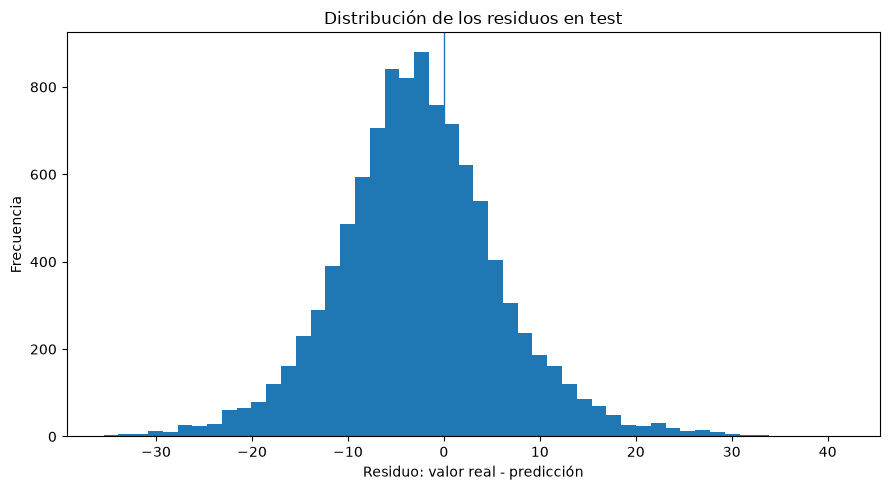

In [25]:
figura, eje = plt.subplots(
    figsize=(9, 5)
)

eje.hist(
    analisis_test["residuo"],
    bins=50
)

eje.axvline(
    0,
    linewidth=1
)

eje.set_title(
    "Distribución de los residuos en test"
)
eje.set_xlabel(
    "Residuo: valor real - predicción"
)
eje.set_ylabel("Frecuencia")

figura.tight_layout()

figura.savefig(
    RUTA_IMAGENES
    / "distribucion_residuos_test.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

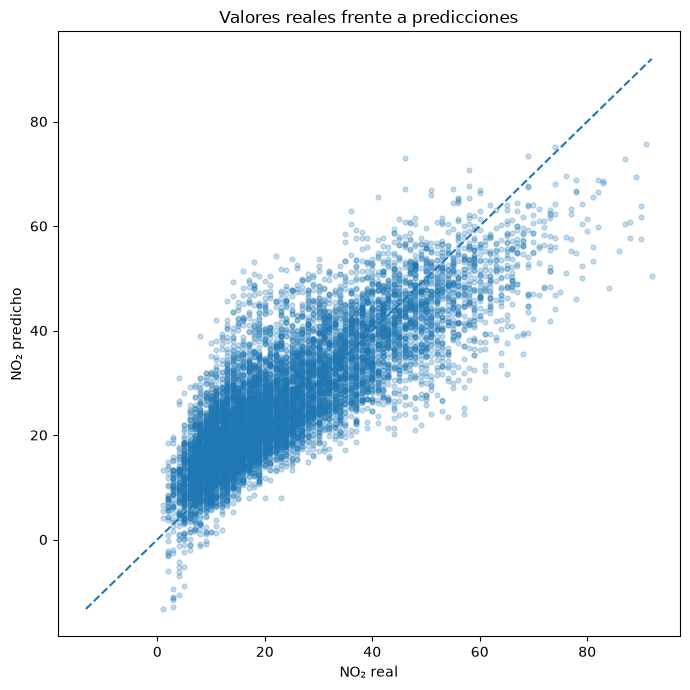

In [26]:
figura, eje = plt.subplots(
    figsize=(7, 7)
)

eje.scatter(
    analisis_test["no2"],
    analisis_test["prediccion"],
    alpha=0.25,
    s=12
)

limite_minimo = min(
    analisis_test["no2"].min(),
    analisis_test["prediccion"].min()
)

limite_maximo = max(
    analisis_test["no2"].max(),
    analisis_test["prediccion"].max()
)

eje.plot(
    [limite_minimo, limite_maximo],
    [limite_minimo, limite_maximo],
    linestyle="--"
)

eje.set_title(
    "Valores reales frente a predicciones"
)
eje.set_xlabel("NO₂ real")
eje.set_ylabel("NO₂ predicho")

figura.tight_layout()

figura.savefig(
    RUTA_IMAGENES
    / "real_vs_predicho_test.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [27]:
peores_predicciones = (
    analisis_test
    .sort_values(
        "error_absoluto",
        ascending=False
    )
    .head(15)
)

peores_predicciones

,fecha,estacion,no2,prediccion,residuo,error_absoluto
1360,2023-11-24,40,92,50.400529,41.599471,41.599471
1357,2023-11-24,36,84,48.083137,35.916863,35.916863
3502,2024-02-22,38,16,51.459441,-35.459441,35.459441
3494,2024-02-22,11,14,49.225898,-35.225898,35.225898
3501,2024-02-22,36,18,53.102306,-35.102306,35.102306
3944,2024-03-12,11,61,27.055163,33.944837,33.944837
10140,2024-11-26,40,65,31.714794,33.285206,33.285206
3954,2024-03-12,40,57,24.067188,32.932812,32.932812
3504,2024-02-22,40,18,50.827840,-32.827840,32.827840
1686,2023-12-08,40,17,49.747586,-32.747586,32.747586


## 14. Interpretabilidad del modelo

Como las variables numéricas se encuentran estandarizadas, sus coeficientes permiten comparar aproximadamente el peso de los cambios de una desviación estándar.

En las variables categóricas, cada coeficiente representa la diferencia respecto a la categoría de referencia implícita del conjunto codificado.

Un coeficiente positivo se asocia con un aumento de la predicción de NO₂ y uno negativo con una reducción, manteniendo constantes las demás variables.

Estas asociaciones no deben interpretarse automáticamente como relaciones causales.

In [28]:
nombres_variables_transformadas = (
    modelo_final
    .named_steps["preprocesado"]
    .get_feature_names_out()
)

coeficientes_modelo = (
    modelo_final
    .named_steps["modelo"]
    .coef_
)

importancia_coeficientes = pd.DataFrame({
    "variable": nombres_variables_transformadas,
    "coeficiente": coeficientes_modelo,
})

importancia_coeficientes[
    "valor_absoluto"
] = importancia_coeficientes[
    "coeficiente"
].abs()

importancia_coeficientes = (
    importancia_coeficientes
    .sort_values(
        "valor_absoluto",
        ascending=False
    )
    .reset_index(drop=True)
)

importancia_coeficientes.head(20)

,variable,coeficiente,valor_absoluto
0,numericas__no2_lag1,8.832330,8.832330
1,numericas__viento_vel,-2.981378,2.981378
2,numericas__dia_anio_cos,2.561999,2.561999
3,numericas__finde,-2.476598,2.476598
4,numericas__humedad,-2.110813,2.110813
5,categoricas__estacion_59,-1.665172,1.665172
6,categoricas__estacion_anio_primavera,-1.619058,1.619058
7,categoricas__estacion_56,1.562528,1.562528
8,numericas__no2_roll_mean_3,1.441690,1.441690
9,categoricas__estacion_49,-1.406400,1.406400


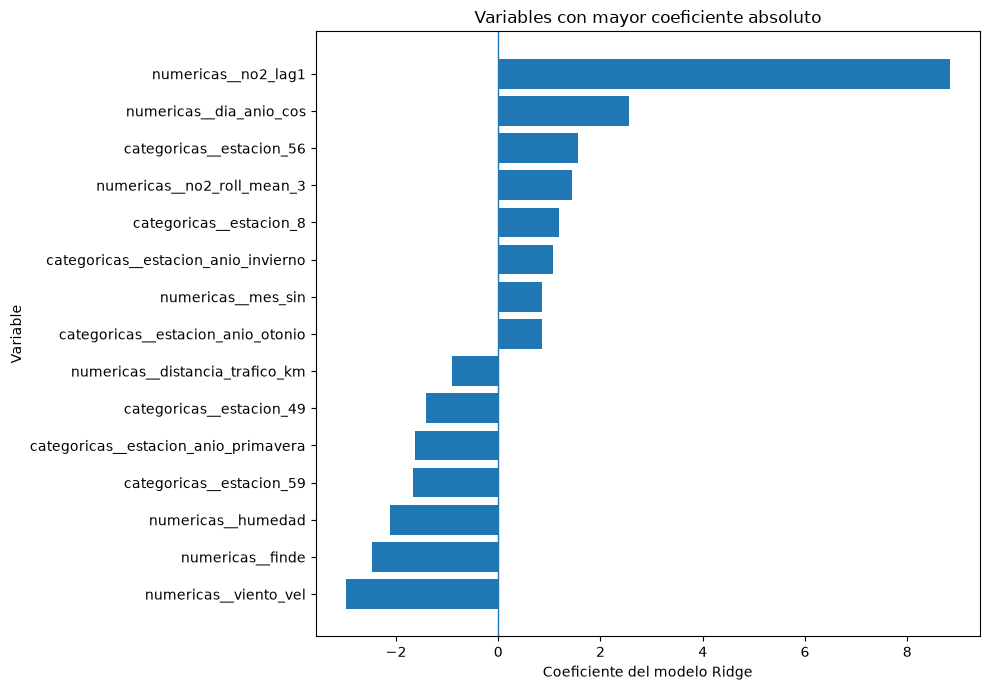

In [29]:
top_coeficientes = (
    importancia_coeficientes
    .head(15)
    .sort_values("coeficiente")
)

figura, eje = plt.subplots(
    figsize=(10, 7)
)

eje.barh(
    top_coeficientes["variable"],
    top_coeficientes["coeficiente"]
)

eje.axvline(
    0,
    linewidth=1
)

eje.set_title(
    "Variables con mayor coeficiente absoluto"
)
eje.set_xlabel(
    "Coeficiente del modelo Ridge"
)
eje.set_ylabel("Variable")

figura.tight_layout()

figura.savefig(
    RUTA_IMAGENES
    / "coeficientes_modelo_ridge.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Principales asociaciones aprendidas

Los resultados muestran que:

- `no2_lag1` es la referencia más importante, confirmando la persistencia temporal del contaminante.
- Una mayor velocidad del viento se asocia con menores concentraciones de NO₂, algo coherente con una mayor dispersión de contaminantes.
- Los fines de semana presentan una asociación negativa, posiblemente relacionada con una menor intensidad de tráfico.
- La estacionalidad anual, la humedad, la estación de medición y las medias móviles también aportan información.
- La influencia de una estación concreta debe interpretarse como una diferencia espacial respecto al resto de localizaciones representadas.

## 15. Guardado del pipeline final

Se guarda el pipeline completo, incluyendo:

- Imputación.
- Escalado.
- One-Hot Encoding.
- Modelo Ridge.

De esta forma, las nuevas observaciones pueden procesarse exactamente con las mismas transformaciones utilizadas durante el entrenamiento.

También se guarda un archivo JSON con las variables, periodos, cobertura y métricas principales.

In [30]:
ruta_modelo = (
    RUTA_MODELOS
    / "modelo_ridge_no2.joblib"
)

ruta_metadata = (
    RUTA_MODELOS
    / "modelo_ridge_no2_metadata.json"
)

joblib.dump(
    modelo_final,
    ruta_modelo
)

metadata = {
    "modelo": "Ridge",
    "alpha": 1000,
    "target": "no2",
    "metrica_principal": "MAE",
    "escenario": (
        "Predicción diaria utilizando la observación "
        "anterior disponible de NO2"
    ),
    "periodo_train": {
        "inicio": str(
            train["fecha"].min().date()
        ),
        "fin": str(
            train["fecha"].max().date()
        ),
    },
    "periodo_test": {
        "inicio": str(
            test["fecha"].min().date()
        ),
        "fin": str(
            test["fecha"].max().date()
        ),
    },
    "filas_train": int(len(train)),
    "filas_test_evaluadas": int(len(test)),
    "cobertura_test": float(cobertura_test),
    "variables_modelo": variables_modelo,
    "variables_excluidas": columnas_excluidas,
    "metricas_test": {
        clave: float(valor)
        for clave, valor
        in metricas_modelo_test.items()
    },
    "metricas_baseline_test": {
        clave: float(valor)
        for clave, valor
        in metricas_baseline_test.items()
    },
    "mejora_mae_porcentaje": float(
        mejora_mae_porcentaje
    ),
}

with open(
    ruta_metadata,
    "w",
    encoding="utf-8"
) as archivo:
    json.dump(
        metadata,
        archivo,
        ensure_ascii=False,
        indent=2
    )

print("Modelo guardado en:")
print(ruta_modelo)

print("\nMetadatos guardados en:")
print(ruta_metadata)

Modelo guardado en:
/Users/victoriabiancon/Desktop/ML_Contaminacion_Madrid/src/models/modelo_ridge_no2.joblib

Metadatos guardados en:
/Users/victoriabiancon/Desktop/ML_Contaminacion_Madrid/src/models/modelo_ridge_no2_metadata.json


## 16. Conclusiones de negocio

El modelo permite estimar la concentración diaria de NO₂ por estación utilizando información que puede estar disponible en un escenario operativo de seguimiento diario.

Su aplicación puede ayudar a:

- Anticipar jornadas con concentraciones elevadas.
- Apoyar la planificación de medidas preventivas.
- Identificar patrones meteorológicos, temporales y espaciales relacionados con el contaminante.
- Complementar sistemas de monitorización cuando existan retrasos puntuales en algunas fuentes de información.

El error medio final es cercano a 7 unidades de NO₂ y el modelo explica aproximadamente dos tercios de la variabilidad observada en el periodo futuro de test.

## 17. Limitaciones

1. El modelo necesita disponer de una observación anterior de NO₂. Por este motivo no puede generar una predicción para el primer registro de cada estación dentro de un bloque independiente.

2. `no2_lag1` representa la observación anterior disponible, que no siempre corresponde exactamente al día anterior cuando existen huecos en las fechas.

3. El modelo identifica asociaciones estadísticas, pero no demuestra relaciones causales.

4. Algunas variables de tráfico presentan un porcentaje elevado de valores ausentes.

5. El rendimiento puede cambiar ante modificaciones estructurales del tráfico, la meteorología, la normativa o la ubicación de las estaciones.

6. El pipeline debería monitorizarse y reentrenarse periódicamente cuando se incorporen nuevos datos.

## 18. Posibles mejoras futuras

- Crear lags basados explícitamente en fechas exactas.
- Incorporar el historial final de train al inicio de test para evitar perder la primera observación de cada estación.
- Evaluar modelos específicos de series temporales.
- Incorporar predicciones meteorológicas en lugar de variables observadas el mismo día.
- Añadir información sobre festivos, episodios extraordinarios y restricciones de tráfico.
- Aplicar técnicas de interpretabilidad local para analizar predicciones concretas.
- Implementar un sistema de monitorización del error y del cambio en la distribución de los datos.

## 19. Correspondencia con las fases del proyecto

Este notebook cubre las siguientes etapas:

- **25.** Selección y justificación de la métrica.
- **26.** Construcción del baseline.
- **27.** Comparación de modelos con validación cruzada.
- **28.** Selección de modelos candidatos.
- **29.** Búsqueda de hiperparámetros.
- **30.** Optimización utilizando exclusivamente train.
- **31.** Análisis de los resultados de validación.
- **32.** Evaluación final sobre test.
- **33.** Análisis de los errores.
- **34.** Interpretabilidad.
- **35.** Traducción de resultados al contexto del proyecto.
- **36.** Persistencia del modelo y sus metadatos.